<a href="https://colab.research.google.com/github/dannynacker/LUCiO/blob/main/LUCIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LUCiO: Lucia Unified Control Interface for OctAVEs

**LUCiO** is an offline sourcecode-generation interface for creating Lucia/RX1-compatible `.lscf` files. It provides three complementary workflows:

```text
LUCiO-Audio          audio-driven sourcecode generation
LUCiO-Composer       typed/manual sourcecode composition
LUCiO-Composer-SUN   typed/manual composition with halogen/wash-light control
```

All modes generate row-based Lucia sourcecodes in which stimulation parameters are written into Lucia-compatible `.lscf` files.

LUCiO-Audio derives stimulation parameters from an uploaded audio file. LUCiO-Composer and LUCiO-Composer-SUN do not use audio; instead, users define a timed sequence directly by specifying duration, oscillator frequency, luminance, duty cycle, and optionally halogen/wash-light intensity.

The current validated implementation uses a **dynamic-duty, header-preserving export mode**. This means that a GUI-authored Lucia sourcecode file is used as a validated binary template, while the sourcecode rows are programmatically replaced with newly generated stimulation parameters.

## Validated Lucia Template

LUCiO currently requires a GUI-authored dynamic-duty `.lscf` template file:

```text
d_spcwkdc1020904022_various.lscf
```

This file acts as a validated header/template carrier. LUCiO preserves the template’s internal Lucia header identity, replaces the row content, and recomputes the final Lucia XOR checksum.

Because the template header is preserved, generated sourcecodes initially appear inside Lucia under the template’s internal display name:

```text
spcwkdc1020904022
```

This is expected. After loading the generated sourcecode in Lucia, it can be saved/resaved through the GUI as a standard session or session configuration with the desired final name.

## Lucia Folder Setup

On the Lucia USB/storage device, generated sourcecode files should be placed in:

```text
user/sourcecodes/
```

In the Lucia sourcecode browser, the files are accessed under the custom category/folder:

```text
D
```

and are usually loaded/saved under:

```text
various
```

In practice, generated files are copied to:

```text
USB Lucia/user/sourcecodes/d_<name>_various.lscf
```

Then loaded in Lucia via:

```text
Session editor → D → various → spcwkdc1020904022
```

Because the internal display name is currently inherited from the validated template, it is best to copy and test **one generated `.lscf` file at a time**. Once loaded and verified, the file can be saved/resaved in Lucia under the desired final session/configuration name.

## Modes

### LUCiO-Audio

LUCiO-Audio converts an uploaded audio file into a row-based Lucia sourcecode. For each control window, the notebook estimates audio-derived stimulation parameters and writes them into OSC1–OSC4.

For each uploaded audio file, LUCiO-Audio exports:

```text
user/sourcecodes/d_<audio_name>_various.lscf
debug/<audio_name>_lucio_debug.csv
plots/<audio_name>_lucio_sequence_plot.png
plots/<audio_name>_lucio_sequence_plot.pdf
```

The debug CSV stores the row-level mapping used to generate the sourcecode, including raw audio frequency, folded SLS frequency, achieved Lucia frequency, RMS amplitude, luminance, raw duty estimate, final duty value, and row timing information.

### LUCiO-Composer

LUCiO-Composer generates Lucia sourcecodes from a typed/manual sequence rather than from audio. Users define a list of timed steps, specifying frequency, luminance, and duty cycle for OSC1–OSC4.

A Composer step can use fixed values:

```python
{
    "label": "alpha_lock",
    "duration": 20,
    "osc1": osc(freq=10, lum=40, duty=50),
    "osc2": osc(freq=10, lum=40, duty=50),
    "osc3": off(),
    "osc4": off(),
}
```

or author-level ramps:

```python
{
    "label": "rise",
    "duration": 30,
    "osc1": ramp(freq=[8, 15], lum=[10, 70], duty=[30, 75]),
    "osc2": ramp(freq=[15, 8], lum=[70, 10], duty=[75, 30]),
    "osc3": osc(freq=60, lum=10, duty=50),
    "osc4": osc(freq=60, lum=10, duty=50),
}
```

Lucia itself does not store native start/end ramp values per row. Instead, LUCiO-Composer expands `[start, end]` ramps into discrete 1-s Lucia rows before export. Each exported Lucia row contains one target state per oscillator.

For each scripted sequence, LUCiO-Composer exports:

```text
user/sourcecodes/d_<sequence_name>_various.lscf
debug/<sequence_name>_lucio_composer_debug.csv
plots/<sequence_name>_lucio_composer_plot.png
plots/<sequence_name>_lucio_composer_plot.pdf
```

### LUCiO-Composer-SUN

LUCiO-Composer-SUN extends LUCiO-Composer with typed halogen/wash-light control. Users can specify a `halogen` value for each authored step, either as a fixed scalar or as a `[start, end]` ramp.

Example halogen-only wash-light ramp:

```python
{
    "label": "halogen_only_rise",
    "duration": 10,
    "halogen": sun([0, 40]),
    "osc1": off(),
    "osc2": off(),
    "osc3": off(),
    "osc4": off(),
}
```

Example combined oscillator and halogen step:

```python
{
    "label": "soft_wash_plus_alpha",
    "duration": 20,
    "halogen": sun(35),
    "osc1": osc(freq=10, lum=20, duty=50),
    "osc2": osc(freq=10, lum=20, duty=50),
    "osc3": osc(freq=60, lum=5, duty=50),
    "osc4": osc(freq=60, lum=5, duty=50),
}
```

As with oscillator ramps, halogen ramps are expanded into discrete Lucia rows before export. Lucia receives one halogen/wash-light value per sourcecode row.

For each SUN sequence, LUCiO-Composer-SUN exports:

```text
user/sourcecodes/d_<sequence_name>_various.lscf
debug/<sequence_name>_lucio_sun_debug.csv
plots/<sequence_name>_lucio_sun_plot.png
plots/<sequence_name>_lucio_sun_plot.pdf
```

The SUN branch uses empirically identified halogen row-control bytes from GUI-authored comparison files:

```text
halogen off: row[40:44] = 00 01 00 14
halogen on:  row[40:44] = 01 01 01 H
```

where `H` is the halogen intensity byte, treated as a 0–100 value.

LUCiO-Composer-SUN has been validated for GUI visibility, loading/playback, halogen ramping, combined halogen-plus-oscillator sequences, and resaving through Lucia as a standard session/session configuration.

## Control Architecture

LUCiO generates Lucia sourcecode rows rather than streaming real-time framewise stimulation. Each row defines the target state for the oscillators, and optionally the halogen/wash-light channel, over a fixed control window.

The current validated settings are:

```text
Control step:              1.0 s
Parameter update rate:     1 Hz
Lucia row duration byte:   10 tenths = 1.0 s
Oscillator frequency:      0–60 Hz
Oscillator duty range:     10–90
Oscillator luminance:      0–100
Halogen/SUN range:         0–100
```

The important distinction is that **1 Hz refers to the parameter update rate**, not the flicker frequency. Within each 1-s row, Lucia generates flicker at the encoded oscillator frequency. The current sourcecode format therefore supports row-based parameter control rather than high-rate framewise modulation.

In LUCiO-Composer and LUCiO-Composer-SUN, longer authored steps are expanded into multiple 1-s sourcecode rows. For example, a 30-s ramp becomes 30 discrete Lucia rows.

## Audio-to-Strobe Mapping

For each 1-s audio window, LUCiO-Audio extracts:

1. **Dominant spectral frequency**
   The dominant audio frequency is estimated within a configurable spectral band and folded by octave into the validated SLS stimulation range.

2. **SLS oscillator frequency**
   The folded SLS frequency is converted into Lucia oscillator cycle units. In the currently validated row grammar, frequency is represented as an integer number of cycles relative to a 2.5-s main-cycle representation, giving an approximate frequency resolution of 0.4 Hz.

3. **Luminance**
   Window-level RMS amplitude is normalized across the track and mapped to a bounded Lucia luminance range.

4. **Duty cycle**
   Duty cycle is dynamically estimated from the within-window audio amplitude envelope. The default method is envelope occupancy: the proportion of the normalized 1-s envelope above a fixed threshold. This produces lower duty values for sparse/transient audio and higher duty values for sustained/dense audio.

The current default LUCiO-Audio mappings are:

```text
SLS frequency range:       4.12–30.87 Hz
Luminance range:           5–50
Duty cycle range:          10–90
Duty method:               envelope occupancy
Duty occupancy threshold:  0.35
```

## Composer Mapping

LUCiO-Composer writes frequency, luminance, and duty values directly from the scripted sequence.

Each oscillator can be controlled independently:

```text
OSC1 frequency / luminance / duty
OSC2 frequency / luminance / duty
OSC3 frequency / luminance / duty
OSC4 frequency / luminance / duty
```

Values can be fixed or ramped. Ramped values are expanded by LUCiO into discrete rows before export.

Composer parameters are clipped to the currently validated bounds:

```text
Frequency range:           0–60 Hz
Luminance range:           0–100
Duty cycle range:          10–90
```

A luminance value of 0 is used for dark/off states. The current validated exporter keeps oscillator blocks structurally active and uses luminance to determine whether visible output is present.

## SUN / Halogen Mapping

LUCiO-Composer-SUN adds a typed `halogen` parameter to the Composer sequence format.

A SUN value can be fixed:

```python
"halogen": sun(35)
```

or ramped:

```python
"halogen": sun([0, 70])
```

The halogen/SUN value is clipped to:

```text
Halogen range:             0–100
```

A value of 0 writes the empirically identified halogen-off row-control pattern:

```text
row[40:44] = 00 01 00 14
```

A value greater than 0 writes the empirically identified halogen-on row-control pattern:

```text
row[40:44] = 01 01 01 H
```

where `H` is the halogen intensity value.

The SUN branch is intended for warm wash-light, ramp-up, ramp-down, dark-reset, and halogen-plus-flicker sequence design.

## Recommended Workflow

1. Open the LUCiO Colab notebook.
2. Choose one of:

   * LUCiO-Audio
   * LUCiO-Composer
   * LUCiO-Composer-SUN
3. Upload the validated dynamic-duty template:

```text
d_spcwkdc1020904022_various.lscf
```

4. For LUCiO-Audio, upload one or more audio files.
5. For LUCiO-Composer, edit the `SEQUENCE_NAME` and `STEPS` section.
6. For LUCiO-Composer-SUN, edit the `SEQUENCE_NAME`, `STEPS`, and any `halogen` / `sun(...)` values.
7. Run the notebook to generate `.lscf`, debug CSV, and sequence plot outputs.
8. Download the generated ZIP.
9. Copy one generated `.lscf` file at a time into:

```text
USB Lucia/user/sourcecodes/
```

10. In Lucia, load:

```text
Session editor → D → various → spcwkdc1020904022
```

11. Verify playback.
12. Save/resave the loaded sourcecode as a normal Lucia session or session configuration using the desired final name.

## Current Validation Status

Validated in LUCiO v0.1:

```text
Full-song .lscf generation
Typed/manual .lscf generation
1-s row-based sourcecode control
Dynamic oscillator frequency
Dynamic oscillator luminance
Dynamic oscillator duty cycle
Independent OSC1–OSC4 control in Composer mode
All-four-oscillator output
Template-header-preserving dynamic-duty mode
Viewable in Lucia sourcecode browser
Playable in Lucia session editor
Resavable as a standard Lucia session/session configuration
```

Validated in LUCiO-Composer-SUN:

```text
Typed halogen/wash-light values
Fixed halogen levels
Halogen ramp expansion
Combined halogen + OSC1–OSC4 scripted sequences
Halogen debug CSV output
Halogen sequence plot output
Viewable/playable generated SUN sourcecodes
Resavable SUN sessions/session configurations
```

Current limitations:

```text
Generated files initially inherit the template’s internal Lucia display name
Only one generated sourcecode should be copied/tested at a time
Control updates are row-based at 1 Hz, not framewise or streamed
Composer ramps are pre-expanded into discrete rows
Lucia rows store target states, not native start/end ramp values
Internal-name rewriting for dynamic-duty sourcecodes is not yet solved
```

Planned extensions:

```text
LUCiO v0.2: dynamic-duty-compatible internal-name/header rewriting
LUCiO-M: multi-band or multi-feature audio mappings
LUCiO-Composer extensions: reusable sequence libraries and named presets
LUCiO-SUN extensions: richer wash-light templates and intensity presets
```

## Methods

LUCiO implements an offline sourcecode-generation interface for Lucia/RX1-compatible stroboscopic stimulation. The current implementation uses a validated GUI-authored dynamic-duty `.lscf` file as a header/template carrier. The template header is preserved, the sourcecode rows are programmatically regenerated, and the final XOR checksum is recomputed.

In LUCiO-Audio, audio files are segmented into 1-s windows, and each window is converted into a Lucia sourcecode row specifying oscillator frequency, luminance, and duty cycle. Dominant audio frequencies are folded by octave into the SLS stimulation range and encoded as Lucia oscillator cycle counts. Window-level RMS amplitude is mapped to luminance, while duty cycle is estimated from amplitude-envelope occupancy within each window.

In LUCiO-Composer, users define a timed sequence directly. Each authored step specifies fixed or ramped frequency, luminance, and duty-cycle values for OSC1–OSC4. Ramps are expanded into one discrete Lucia row per control step before export.

In LUCiO-Composer-SUN, users may additionally specify a halogen/wash-light value per authored step. Halogen values may be fixed or ramped and are expanded into one discrete Lucia row per control step. The SUN implementation uses empirically identified row-control bytes for halogen-off and halogen-on states.

Generated files are viewable and playable in Lucia and can be resaved through the GUI as standard session/session configuration files.

## Technical Notes

The validated `.lscf` structure used by LUCiO follows:

```text
Header:     132 bytes
Rows:       56 bytes each
Checksum:   final 1-byte XOR checksum
```

The final byte is recomputed as the XOR of all preceding bytes. In the current dynamic-duty mode, the header is preserved exactly from the validated GUI-authored template, and only the row sequence plus final XOR checksum are regenerated.

Each 56-byte row contains four oscillator blocks, global oscillator luminance/activation fields, timing/control bytes, loop information, and row-control bytes used for halogen/wash-light behaviour.

Duty-cycle bytes are written directly as decimal percentage values in the valid Lucia GUI range of 10–90. For all-four-oscillator rows, these are located at row-relative offsets:

```text
OSC1 duty:  3
OSC2 duty:  11
OSC3 duty:  19
OSC4 duty:  27
```

The currently validated timing/control convention uses:

```text
row duration: 1.0 s
row[48]:      10
loops:        1
```

Frequency is encoded as an integer cycle count relative to the row’s main-cycle representation. In the currently validated template, this gives an approximate frequency resolution of 0.4 Hz.

The SUN/halogen branch uses the following row-control patterns:

```text
halogen off: row[40:44] = 00 01 00 14
halogen on:  row[40:44] = 01 01 01 H
```

where `H` is the halogen intensity value, currently treated as 0–100.

## Credit

LUCiO was developed as part of the octAVEs-to-stroboscopic-light workflow for generating Lucia/RX1-compatible sourcecodes from audio-derived and manually authored stimulation features. The current implementation is reverse-engineered and validated empirically through GUI loading/playback tests and should be treated as a practical compatibility layer rather than an official Lucia/RX1 specification.


LUCIO-D sourcecode export

Step 1: upload the validated dynamic-duty Lucia template:
  d_spcwkdc1020904022_various.lscf



Saving d_spcwkdc1020904022_various.lscf to d_spcwkdc1020904022_various (3).lscf
Template loaded
  File: d_spcwkdc1020904022_various (3).lscf
  Lucia display name: spcwkdc1020904022
  Template rows: 461
  First-row OSC duties: [10, 10, 10, 10]

Step 2: upload one or more audio files
Supported: wav, mp3, flac, m4a, ogg, aiff



Saving DJS_space_walk.mp3 to DJS_space_walk (1).mp3
------------------------------------------------------------
Processing: DJS_space_walk (1).mp3
  Duration: 460.30 s
  Output file: d_djsspacewalk1_various.lscf
  Lucia display name: spcwkdc1020904022
  Control step: 1.00 s


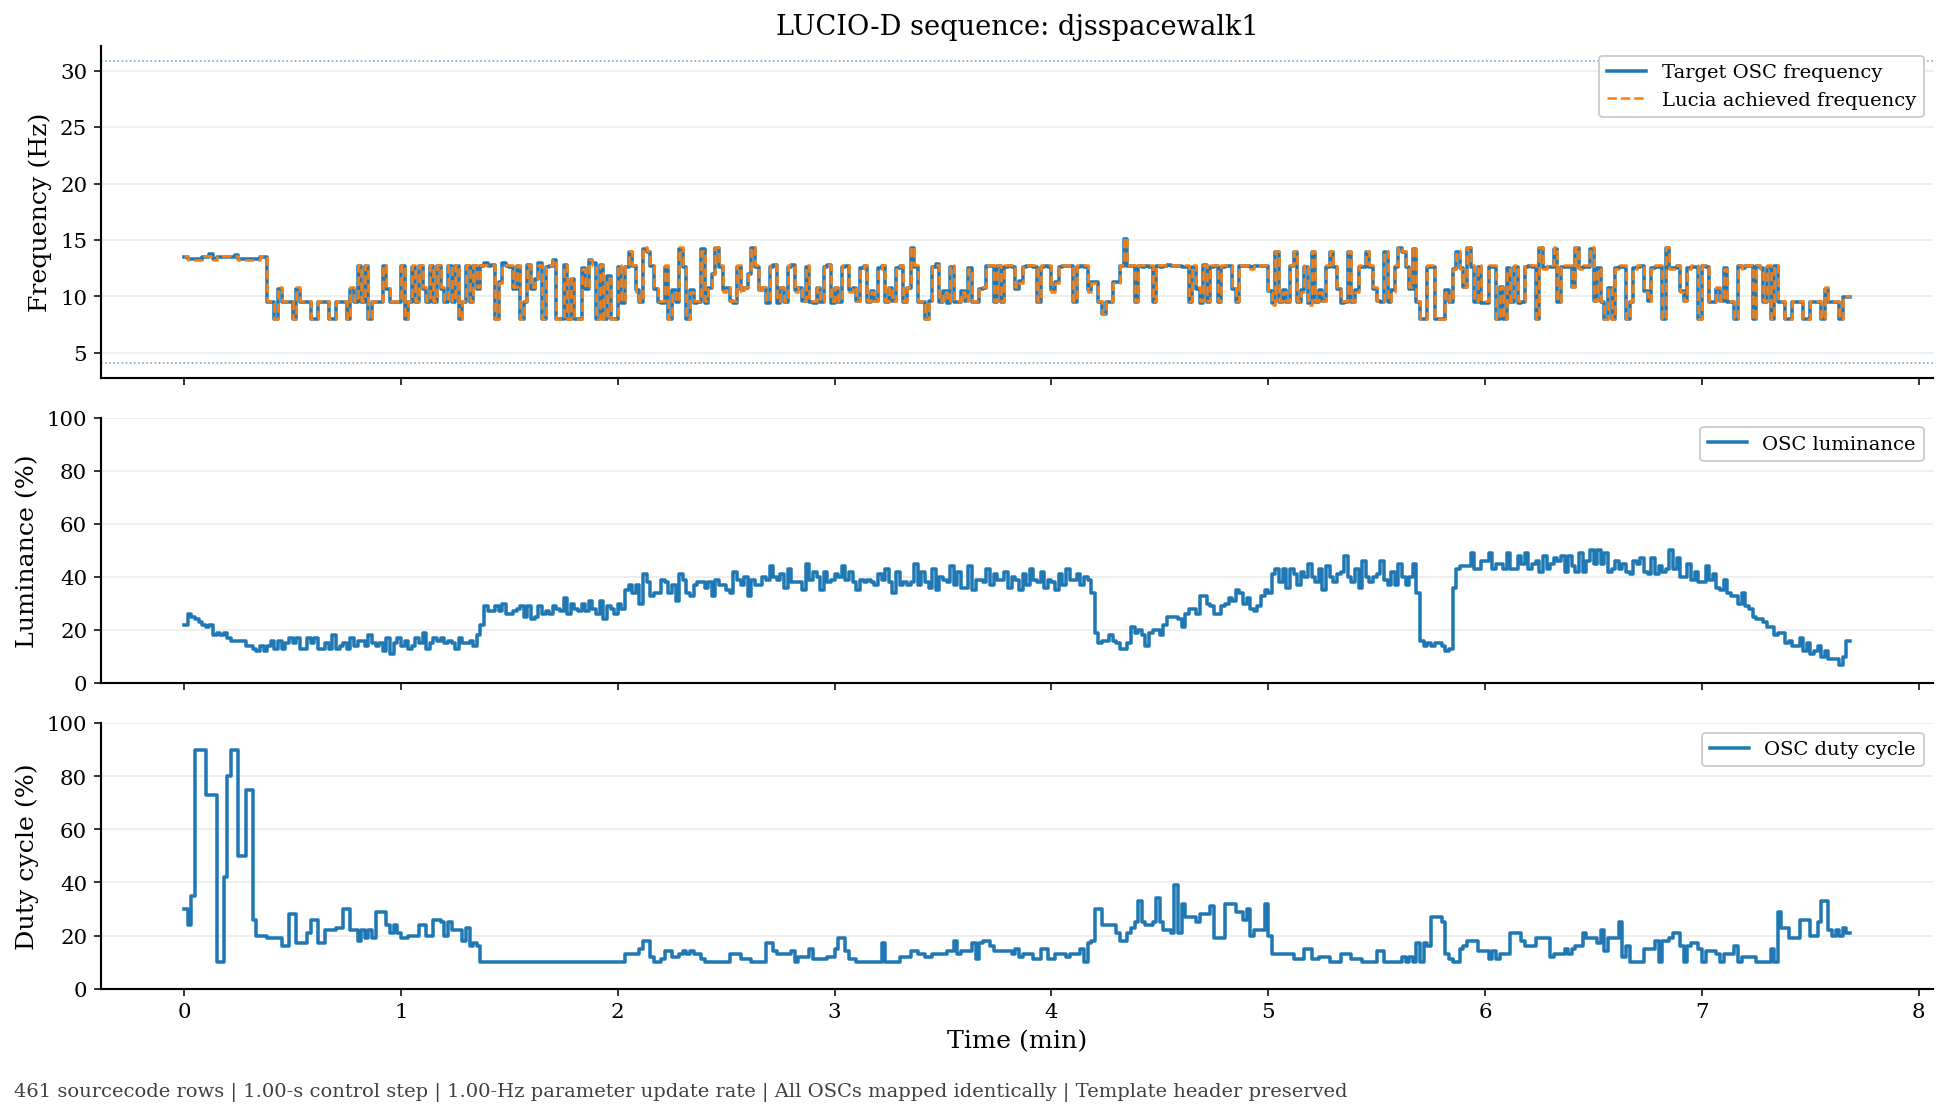

  Rows written: 461
  Approx duration: 461.00 s
  Achieved frequency: 8.00–15.20 Hz
  Luminance: 7–50
  Duty cycle: 10–90
  Checksum valid: True

LUCIO-D export complete
Copy one generated .lscf file at a time into:
  USB Lucia/user/sourcecodes/

Then load in Lucia:
  Session editor -> D -> various -> spcwkdc1020904022

The output filename is audio-specific, but the initial Lucia display
name is inherited from the validated template. After loading, resave
the sourcecode/session in Lucia under the desired final name.

Export settings:
  Control step: 1.00 s
  Parameter update rate: 1.00 Hz
  Duty method: occupancy
  Duty bounds: 10–90
  Luminance bounds: 5–50


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# LUCiO
# Lucia Unified Control Interface for OctAVEs
# Dynamic-duty sourcecode export for Lucia/RX1
# ============================================================
#
# Purpose
# -------
# Converts an audio file into a Lucia/RX1-compatible .lscf sourcecode.
# The generated sourcecode contains one row per control window and maps
# audio-derived features to:
#
#   - oscillator frequency
#   - oscillator luminance
#   - oscillator duty cycle
#
# Validated template
# ------------------
# Use the GUI-authored dynamic-duty template:
#
#   d_spcwkdc1020904022_various.lscf
#
# This template's header/internal identity is preserved. Therefore, inside
# Lucia, generated sourcecodes will initially appear under the template's
# internal display name:
#
#   spcwkdc1020904022
#
# After loading in Lucia, the sourcecode can be saved/resaved as a normal
# session or session configuration with the desired final name.
#
# Output
# ------
#   user/sourcecodes/d_<audio_name>_various.lscf
#   debug/<audio_name>_lucio_debug.csv
#   plots/<audio_name>_lucio_sequence_plot.png
#   plots/<audio_name>_lucio_sequence_plot.pdf
#
# Recommended use
# ---------------
# Copy one generated .lscf at a time into:
#
#   USB Lucia/user/sourcecodes/
#
# Then load in Lucia:
#
#   Session editor -> D -> various -> spcwkdc1020904022
#
# ============================================================

!pip -q install librosa soundfile numpy pandas scipy matplotlib

from __future__ import annotations

import math
import re
import struct
import zipfile
from dataclasses import dataclass
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import hilbert

from google.colab import files


# ============================================================
# CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class LucioConfig:
    # Row/control timing
    control_step_seconds: float = 1.0
    displayed_seconds_tenths: int = 10
    loops_per_row: int = 1

    # Luminance mapping
    luminance_min: int = 5
    luminance_max: int = 50

    # Duty-cycle mapping: "occupancy", "mean_envelope", or "fixed"
    duty_method: str = "occupancy"
    duty_fixed: int = 50
    duty_min: int = 10
    duty_max: int = 90
    duty_fallback: int = 50
    duty_invert: bool = False
    duty_occupancy_threshold: float = 0.35

    # Optional duty shaping
    duty_smooth_rows: int | None = 3
    duty_quantize_step: int | None = 1
    duty_max_row_change: int | None = None

    # Audio spectral extraction
    audio_band_low_hz: float = 40.0
    audio_band_high_hz: float = 6000.0

    # SLS frequency range
    sls_min_hz: float = 4.12
    sls_max_hz: float = 30.87
    sls_center_hz: float = 11.56

    # Plotting
    make_sequence_plot: bool = True
    time_units: str = "min"


CFG = LucioConfig()


# ============================================================
# LUCIA/RX1 BINARY CONSTANTS
# ============================================================

HEADER_LEN = 132
ROW_LEN = 56
CHECKSUM_LEN = 1

NAME_FIELD_OFFSET = 24
NAME_FIELD_LEN = 56

DUTY_OFFSETS = [3, 11, 19, 27]


# ============================================================
# LOW-LEVEL LUCIA HELPERS
# ============================================================

def lucia_xor_checksum(data_without_checksum: bytes) -> int:
    checksum = 0
    for byte in data_without_checksum:
        checksum ^= byte
    return checksum


def finalize_lucia_file(buffer: bytearray) -> bytearray:
    buffer = bytearray(buffer)
    buffer[-1] = lucia_xor_checksum(buffer[:-1])
    return buffer


def verify_lucia_checksum(data: bytes) -> bool:
    return data[-1] == lucia_xor_checksum(data[:-1])


def read_internal_name(data: bytes) -> str:
    raw = bytes(data[NAME_FIELD_OFFSET:NAME_FIELD_OFFSET + NAME_FIELD_LEN])
    raw = raw.split(b"\x00", 1)[0]
    return raw.decode("ascii", errors="replace")


def sanitize_filename_stem(name: str, max_len: int = 18) -> str:
    stem = Path(str(name)).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "", stem)

    if not stem:
        stem = "lucio"

    if stem[0].isdigit():
        stem = "l" + stem

    return stem[:max_len]


def parse_lucia_rows(data: bytes) -> list[bytearray]:
    n_rows = (len(data) - HEADER_LEN - CHECKSUM_LEN) // ROW_LEN
    expected_len = HEADER_LEN + n_rows * ROW_LEN + CHECKSUM_LEN

    if len(data) != expected_len:
        raise ValueError(
            f"Invalid .lscf size: {len(data)} bytes. "
            f"Expected 132 + 56*N + 1 bytes."
        )

    return [
        bytearray(data[HEADER_LEN + i * ROW_LEN:HEADER_LEN + (i + 1) * ROW_LEN])
        for i in range(n_rows)
    ]


def main_cycle_seconds_from_row(row: bytes) -> float:
    stored = struct.unpack("<H", bytes(row[44:46]))[0]
    if stored <= 0:
        return 2.5
    return 2500.0 / float(stored)


def clamp_byte(value: float) -> int:
    return int(np.clip(round(float(value)), 0, 255))


def cycles_from_hz(freq_hz: float, main_cycle_seconds: float) -> int:
    cycles = int(round(float(freq_hz) * float(main_cycle_seconds)))
    return int(np.clip(cycles, 1, 255))


# ============================================================
# AUDIO FEATURE EXTRACTION
# ============================================================

def octave_candidates(freq_hz: float, max_pow: int = 14) -> list[float]:
    if freq_hz <= 0:
        return []
    return [float(freq_hz) * (2.0 ** k) for k in range(-max_pow, max_pow + 1)]


def fold_frequency_to_sls_range(freq_hz: float, cfg: LucioConfig = CFG) -> float:
    if freq_hz <= 0:
        return cfg.sls_center_hz

    candidates = [
        f for f in octave_candidates(freq_hz)
        if cfg.sls_min_hz <= f <= cfg.sls_max_hz
    ]

    if candidates:
        candidates.sort(key=lambda f: abs(f - cfg.sls_center_hz))
        return float(candidates[0])

    folded = float(freq_hz)

    for _ in range(64):
        if folded < cfg.sls_min_hz:
            folded *= 2.0
        elif folded > cfg.sls_max_hz:
            folded /= 2.0
        else:
            break

    return float(np.clip(folded, cfg.sls_min_hz, cfg.sls_max_hz))


def next_power_of_two(n: int) -> int:
    return 1 << (int(n) - 1).bit_length()


def dominant_frequency_for_segment(
    segment: np.ndarray,
    sr: int,
    cfg: LucioConfig = CFG
) -> float:
    segment = np.asarray(segment, dtype=np.float32)

    if len(segment) < 16 or np.max(np.abs(segment)) <= 0:
        return cfg.sls_center_hz

    window = np.hanning(len(segment)).astype(np.float32)
    n_fft = max(4096, next_power_of_two(len(segment)))

    spectrum = np.abs(np.fft.rfft(segment * window, n=n_fft))
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / sr)

    band = (freqs >= cfg.audio_band_low_hz) & (freqs <= cfg.audio_band_high_hz)

    if not np.any(band):
        return cfg.sls_center_hz

    band_spectrum = spectrum[band]
    band_freqs = freqs[band]

    if len(band_spectrum) == 0 or np.max(band_spectrum) <= 0:
        return cfg.sls_center_hz

    return float(band_freqs[int(np.argmax(band_spectrum))])


def raw_duty_for_segment(segment: np.ndarray, cfg: LucioConfig = CFG) -> float:
    method = cfg.duty_method.lower().strip()

    if method == "fixed":
        return float(cfg.duty_fixed)

    segment = np.asarray(segment, dtype=np.float32)

    if len(segment) < 16 or np.max(np.abs(segment)) <= 0:
        return float(cfg.duty_fallback)

    envelope = np.abs(hilbert(segment.astype(np.float64)))
    peak = float(np.max(envelope))

    if peak <= 1e-12:
        return float(cfg.duty_fallback)

    envelope_norm = envelope / peak

    if method == "occupancy":
        duty = 100.0 * float(np.mean(envelope_norm > cfg.duty_occupancy_threshold))
    elif method == "mean_envelope":
        duty = 100.0 * float(np.mean(envelope_norm))
    else:
        raise ValueError(
            f"Unknown duty method: {cfg.duty_method}. "
            "Use 'occupancy', 'mean_envelope', or 'fixed'."
        )

    if cfg.duty_invert:
        duty = 100.0 - duty

    return float(duty)


def shape_duty_series(
    duty_values: np.ndarray,
    cfg: LucioConfig = CFG
) -> np.ndarray:
    duty = pd.Series(np.asarray(duty_values, dtype=float))
    duty = duty.clip(cfg.duty_min, cfg.duty_max)

    if cfg.duty_smooth_rows is not None and cfg.duty_smooth_rows > 1:
        duty = duty.rolling(
            window=int(cfg.duty_smooth_rows),
            center=True,
            min_periods=1
        ).median()

    duty_array = duty.to_numpy(dtype=float)

    if cfg.duty_max_row_change is not None and cfg.duty_max_row_change > 0:
        shaped = np.zeros_like(duty_array)
        shaped[0] = duty_array[0]

        for i in range(1, len(duty_array)):
            delta = duty_array[i] - shaped[i - 1]
            delta = np.clip(delta, -cfg.duty_max_row_change, cfg.duty_max_row_change)
            shaped[i] = shaped[i - 1] + delta

        duty_array = shaped

    if cfg.duty_quantize_step is not None and cfg.duty_quantize_step > 0:
        duty_array = np.round(duty_array / cfg.duty_quantize_step) * cfg.duty_quantize_step

    duty_array = np.clip(
        np.round(duty_array),
        cfg.duty_min,
        cfg.duty_max
    ).astype(int)

    return duty_array


def extract_audio_control_table(
    audio_path: str,
    cfg: LucioConfig = CFG
) -> pd.DataFrame:
    y, sr = librosa.load(audio_path, sr=None, mono=True)
    y = y.astype(np.float32)

    step_samples = int(round(sr * cfg.control_step_seconds))

    if step_samples <= 0:
        raise ValueError("control_step_seconds must be positive.")

    n_steps = int(math.ceil(len(y) / step_samples))
    rows = []

    for i in range(n_steps):
        start = i * step_samples
        stop = min(len(y), start + step_samples)
        segment = y[start:stop]

        if len(segment) == 0:
            continue

        raw_freq = dominant_frequency_for_segment(segment, sr, cfg)
        sls_freq = fold_frequency_to_sls_range(raw_freq, cfg)

        rms = float(np.sqrt(np.mean(segment ** 2))) if len(segment) else 0.0
        duty_raw = raw_duty_for_segment(segment, cfg)

        rows.append({
            "row": i + 1,
            "time_sec": i * cfg.control_step_seconds,
            "raw_freq_hz": raw_freq,
            "sls_freq_hz": sls_freq,
            "rms": rms,
            "duty_raw": duty_raw
        })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No control rows extracted from {audio_path}")

    rms_max = float(df["rms"].max())
    if rms_max <= 0:
        rms_max = 1.0

    df["amp_norm"] = df["rms"] / rms_max
    df["luminance"] = (
        cfg.luminance_min
        + df["amp_norm"] * (cfg.luminance_max - cfg.luminance_min)
    ).round().clip(cfg.luminance_min, cfg.luminance_max).astype(int)

    df["duty"] = shape_duty_series(df["duty_raw"].values, cfg)

    return df


# ============================================================
# LUCIA ROW GENERATION
# ============================================================

def patch_lucia_row(
    template_row: bytes,
    control_row: pd.Series,
    cfg: LucioConfig = CFG
) -> tuple[bytearray, dict]:
    row = bytearray(template_row)

    main_cycle_seconds = main_cycle_seconds_from_row(row)

    freq_hz = float(control_row["sls_freq_hz"])
    luminance = int(control_row["luminance"])
    duty = int(control_row["duty"])
    cycles = cycles_from_hz(freq_hz, main_cycle_seconds)

    for osc in range(4):
        base = osc * 8

        row[base + 0] = 1
        row[base + 1] = 1
        row[base + 2] = 100
        row[base + 3] = clamp_byte(duty)
        row[base + 4] = clamp_byte(cycles)
        row[base + 5] = 0
        row[base + 6] = 1
        row[base + 7] = 0

    for osc in range(4):
        row[32 + osc] = clamp_byte(luminance)
        row[36 + osc] = 1

    # Validated D/various halogen-off grammar.
    row[40:44] = bytes([0x00, 0x01, 0x00, 0x14])

    # Sourcecode row timing/control convention.
    row[46] = 1
    row[47] = 1
    row[48] = clamp_byte(cfg.displayed_seconds_tenths)
    row[49] = 0
    row[50] = 0
    row[51] = 0

    row[52:56] = struct.pack("<I", int(cfg.loops_per_row))

    debug = {
        "main_cycle_seconds": main_cycle_seconds,
        "displayed_row_seconds": row[48] / 10.0,
        "cycles": cycles,
        "achieved_freq_hz": cycles / main_cycle_seconds,
        "row_40_56_hex": row[40:56].hex(" ")
    }

    return row, debug


def build_lucia_sourcecode(
    template_data: bytes,
    control_df: pd.DataFrame,
    output_path: str,
    cfg: LucioConfig = CFG
) -> tuple[str, pd.DataFrame]:
    template_data = bytearray(template_data)
    template_rows = parse_lucia_rows(template_data)
    template_row = template_rows[0]

    out = bytearray()
    out.extend(template_data[:HEADER_LEN])

    debug_rows = []

    for _, control_row in control_df.iterrows():
        patched_row, row_debug = patch_lucia_row(template_row, control_row, cfg)
        out.extend(patched_row)

        debug_row = dict(control_row)
        debug_row.update(row_debug)
        debug_rows.append(debug_row)

    out.extend(b"\x00")
    out = finalize_lucia_file(out)

    if not verify_lucia_checksum(out):
        raise RuntimeError("Final Lucia XOR checksum failed.")

    Path(output_path).write_bytes(out)

    return output_path, pd.DataFrame(debug_rows)


# ============================================================
# SEQUENCE PLOT
# ============================================================

def make_sequence_plot(
    debug_df: pd.DataFrame,
    stem: str,
    cfg: LucioConfig = CFG
) -> tuple[str, str]:
    time_sec = debug_df["time_sec"].to_numpy(dtype=float)

    if cfg.time_units.lower().startswith("min"):
        t = time_sec / 60.0
        final_t = (time_sec[-1] + cfg.control_step_seconds) / 60.0
        x_label = "Time (min)"
    else:
        t = time_sec
        final_t = time_sec[-1] + cfg.control_step_seconds
        x_label = "Time (s)"

    t_step = np.append(t, final_t)

    def step_values(values):
        values = np.asarray(values, dtype=float)
        return np.append(values, values[-1])

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Palatino", "Palatino Linotype", "DejaVu Serif"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.1,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "figure.dpi": 140,
    })

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [1.25, 1.0, 1.0]}
    )

    ax_freq, ax_lum, ax_duty = axes

    ax_freq.step(
        t_step,
        step_values(debug_df["sls_freq_hz"]),
        where="post",
        linewidth=1.8,
        label="Target OSC frequency"
    )
    ax_freq.step(
        t_step,
        step_values(debug_df["achieved_freq_hz"]),
        where="post",
        linewidth=1.3,
        linestyle="--",
        label="Lucia achieved frequency"
    )
    ax_freq.axhline(cfg.sls_min_hz, linewidth=0.8, linestyle=":", alpha=0.7)
    ax_freq.axhline(cfg.sls_max_hz, linewidth=0.8, linestyle=":", alpha=0.7)
    ax_freq.set_ylabel("Frequency (Hz)")
    ax_freq.set_title(f"LUCIO-D sequence: {stem}")
    ax_freq.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_freq.grid(axis="y", alpha=0.25)

    ax_lum.step(
        t_step,
        step_values(debug_df["luminance"]),
        where="post",
        linewidth=1.8,
        label="OSC luminance"
    )
    ax_lum.set_ylabel("Luminance (%)")
    ax_lum.set_ylim(0, max(100, float(debug_df["luminance"].max()) * 1.1))
    ax_lum.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_lum.grid(axis="y", alpha=0.25)

    ax_duty.step(
        t_step,
        step_values(debug_df["duty"]),
        where="post",
        linewidth=1.8,
        label="OSC duty cycle"
    )
    ax_duty.set_ylabel("Duty cycle (%)")
    ax_duty.set_ylim(0, 100)
    ax_duty.set_xlabel(x_label)
    ax_duty.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_duty.grid(axis="y", alpha=0.25)

    footer = (
        f"{len(debug_df)} sourcecode rows | "
        f"{cfg.control_step_seconds:.2f}-s control step | "
        f"{1 / cfg.control_step_seconds:.2f}-Hz parameter update rate | "
        "All OSCs mapped identically | "
        "Template header preserved"
    )

    fig.text(0.01, 0.01, footer, ha="left", va="bottom", fontsize=10, alpha=0.75)
    plt.tight_layout(rect=[0, 0.035, 1, 1])

    png_path = f"/content/{stem}_lucio_sequence_plot.png"
    pdf_path = f"/content/{stem}_lucio_sequence_plot.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    return png_path, pdf_path


# ============================================================
# COLAB RUNNER
# ============================================================

print("LUCIO-D sourcecode export")
print("")
print("Step 1: upload the validated dynamic-duty Lucia template:")
print("  d_spcwkdc1020904022_various.lscf")
print("")

template_upload = files.upload()

template_filename = next(iter(template_upload.keys()))
template_data = bytearray(Path(template_filename).read_bytes())
template_rows = parse_lucia_rows(template_data)

if not verify_lucia_checksum(template_data):
    raise RuntimeError("Template checksum is invalid.")

template_display_name = read_internal_name(template_data)

print("Template loaded")
print(f"  File: {template_filename}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Template rows: {len(template_rows)}")
print(f"  First-row OSC duties: {[template_rows[0][off] for off in DUTY_OFFSETS]}")
print("")

print("Step 2: upload one or more audio files")
print("Supported: wav, mp3, flac, m4a, ogg, aiff")
print("")

audio_upload = files.upload()

audio_exts = {".wav", ".mp3", ".flac", ".m4a", ".ogg", ".aiff", ".aif"}
audio_paths = [
    Path(filename)
    for filename in audio_upload.keys()
    if Path(filename).suffix.lower() in audio_exts
]

if not audio_paths:
    raise ValueError("No supported audio files were uploaded.")

outputs = []

for audio_path in audio_paths:
    audio_stem = sanitize_filename_stem(audio_path.stem, max_len=18)

    lscf_path = f"/content/d_{audio_stem}_various.lscf"
    debug_path = f"/content/{audio_stem}_lucio_debug.csv"

    info = sf.info(str(audio_path))
    duration_sec = info.frames / info.samplerate

    print("------------------------------------------------------------")
    print(f"Processing: {audio_path.name}")
    print(f"  Duration: {duration_sec:.2f} s")
    print(f"  Output file: {Path(lscf_path).name}")
    print(f"  Lucia display name: {template_display_name}")
    print(f"  Control step: {CFG.control_step_seconds:.2f} s")

    control_df = extract_audio_control_table(str(audio_path), CFG)

    _, debug_df = build_lucia_sourcecode(
        template_data=template_data,
        control_df=control_df,
        output_path=lscf_path,
        cfg=CFG
    )

    debug_df.to_csv(debug_path, index=False)

    plot_paths = []
    if CFG.make_sequence_plot:
        plot_paths = list(make_sequence_plot(debug_df, audio_stem, CFG))

    print(f"  Rows written: {len(debug_df)}")
    print(f"  Approx duration: {len(debug_df) * CFG.control_step_seconds:.2f} s")
    print(
        f"  Achieved frequency: "
        f"{debug_df['achieved_freq_hz'].min():.2f}–"
        f"{debug_df['achieved_freq_hz'].max():.2f} Hz"
    )
    print(
        f"  Luminance: "
        f"{int(debug_df['luminance'].min())}–"
        f"{int(debug_df['luminance'].max())}"
    )
    print(
        f"  Duty cycle: "
        f"{int(debug_df['duty'].min())}–"
        f"{int(debug_df['duty'].max())}"
    )
    print(f"  Checksum valid: {verify_lucia_checksum(Path(lscf_path).read_bytes())}")
    print("")

    outputs.append((lscf_path, debug_path, plot_paths))

zip_path = "/content/lucio_d_exports.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for lscf_path, debug_path, plot_paths in outputs:
        z.write(lscf_path, arcname=f"user/sourcecodes/{Path(lscf_path).name}")
        z.write(debug_path, arcname=f"debug/{Path(debug_path).name}")

        for plot_path in plot_paths:
            z.write(plot_path, arcname=f"plots/{Path(plot_path).name}")

print("============================================================")
print("LUCIO-D export complete")
print("============================================================")
print("Copy one generated .lscf file at a time into:")
print("  USB Lucia/user/sourcecodes/")
print("")
print("Then load in Lucia:")
print(f"  Session editor -> D -> various -> {template_display_name}")
print("")
print("The output filename is audio-specific, but the initial Lucia display")
print("name is inherited from the validated template. After loading, resave")
print("the sourcecode/session in Lucia under the desired final name.")
print("")
print("Export settings:")
print(f"  Control step: {CFG.control_step_seconds:.2f} s")
print(f"  Parameter update rate: {1 / CFG.control_step_seconds:.2f} Hz")
print(f"  Duty method: {CFG.duty_method}")
print(f"  Duty bounds: {CFG.duty_min}–{CFG.duty_max}")
print(f"  Luminance bounds: {CFG.luminance_min}–{CFG.luminance_max}")
print("============================================================")

files.download(zip_path)

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

Saving d_spcwkdc1020904022_various.lscf to d_spcwkdc1020904022_various.lscf
Template loaded
  File: d_spcwkdc1020904022_various.lscf
  Lucia display name: spcwkdc1020904022
  Template rows: 461
  First-row OSC duties: [10, 10, 10, 10]

Expanding scripted sequence


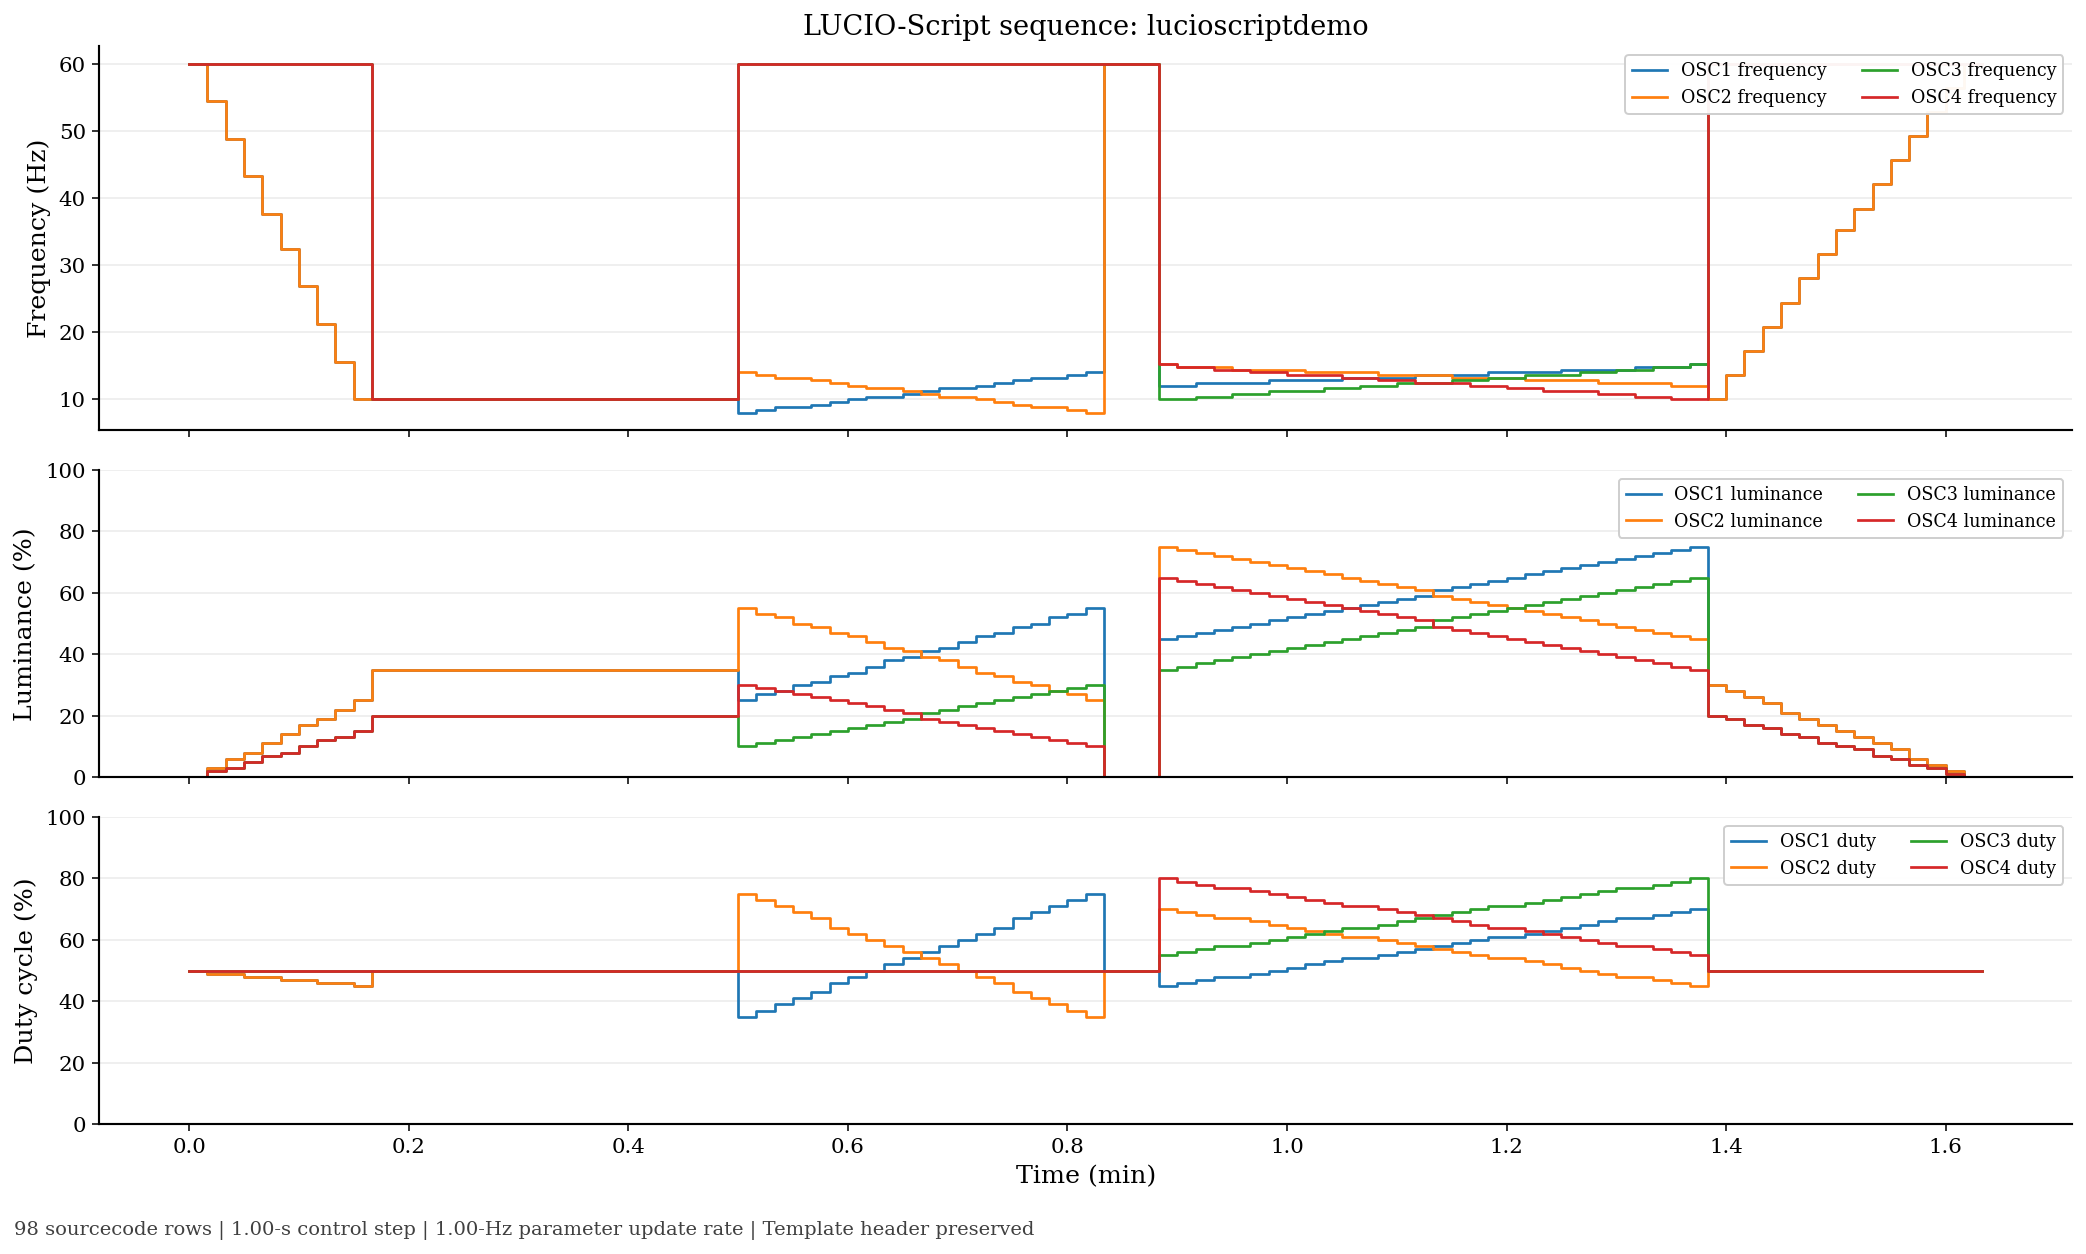

Export summary
  Sequence name: lucioscriptdemo
  Output file: d_lucioscriptdemo_various.lscf
  Lucia display name: spcwkdc1020904022
  Rows written: 98
  Approx exported duration: 98.00 s
  Checksum valid: True

  OSC1: freq 8.00–60.00 Hz | lum 0–75 | duty 35–75
  OSC2: freq 8.00–60.00 Hz | lum 0–75 | duty 35–75
  OSC3: freq 10.00–60.00 Hz | lum 0–65 | duty 50–80
  OSC4: freq 10.00–60.00 Hz | lum 0–65 | duty 50–80

LUCIO-Script export complete
Copy the generated .lscf file into:
  USB Lucia/user/sourcecodes/

Then load in Lucia:
  Session editor -> D -> various -> spcwkdc1020904022

The output filename is sequence-specific, but the initial Lucia display
name is inherited from the validated template. After loading, resave
the sourcecode/session in Lucia under the desired final name.

Export settings:
  Control step: 1.00 s
  Parameter update rate: 1.00 Hz
  Row duration byte: 10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# LUCiO-Composer
# Lucia Unified Control Interface for OctAVEs
# Scripted sourcecode export for Lucia/RX1
# ============================================================
#
# Purpose
# -------
# Generates a Lucia/RX1-compatible .lscf sourcecode from a hand-authored
# sequence rather than from audio.
#
# Each authored step can specify OSC1-OSC4 frequency, luminance, and duty.
# Values may be fixed scalars or [start, end] pairs. [start, end] pairs
# are expanded by LUCiO into one discrete Lucia row per control step.
#
# Validated template
# ------------------
# Upload the GUI-authored dynamic-duty template:
#
#   d_spcwkdc1020904022_various.lscf
#
# This template's header/internal identity is preserved. Therefore, inside
# Lucia, generated sourcecodes will initially appear under the template's
# internal display name:
#
#   spcwkdc1020904022
#
# After loading in Lucia, save/resave as a normal session/session config
# with the desired final name.
#
# Output
# ------
#   user/sourcecodes/d_<sequence_name>_various.lscf
#   debug/<sequence_name>_lucio_script_debug.csv
#   plots/<sequence_name>_lucio_script_plot.png
#   plots/<sequence_name>_lucio_script_plot.pdf
#
# Recommended use
# ---------------
# Copy one generated .lscf at a time into:
#
#   USB Lucia/user/sourcecodes/
#
# Then load in Lucia:
#
#   Session editor -> D -> various -> spcwkdc1020904022
#
# ============================================================

!pip -q install numpy pandas matplotlib

from __future__ import annotations

import math
import re
import struct
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files


# ============================================================
# CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class LucioScriptConfig:
    # Lucia export resolution.
    # 1.0 s is the validated default.
    control_step_seconds: float = 1.0
    displayed_seconds_tenths: int = 10
    loops_per_row: int = 1

    # Parameter bounds.
    freq_min_hz: float = 0.0
    freq_max_hz: float = 60.0
    luminance_min: int = 0
    luminance_max: int = 100
    duty_min: int = 10
    duty_max: int = 90

    # Defaults for missing oscillator fields.
    default_freq_hz: float = 60.0
    default_luminance: int = 0
    default_duty: int = 50

    # Keep OSC blocks structurally active and use luminance=0 for off states.
    # This matches the most stable LUCIO-D behaviour.
    keep_all_oscillators_active: bool = True

    # Plotting.
    make_sequence_plot: bool = True
    time_units: str = "min"


CFG = LucioScriptConfig()


# ============================================================
# SCRIPTED SEQUENCE
# ============================================================
#
# Authoring rules:
#
# 1. Each step needs a duration in seconds.
#
# 2. Each oscillator can be specified as "osc1", "osc2", "osc3", "osc4".
#
# 3. Frequency, luminance, and duty may be:
#      - scalar: fixed for the step
#      - [start, end]: linearly expanded across exported rows
#
# 4. Missing oscillator fields fall back to:
#      freq = 60 Hz, luminance = 0, duty = 50
#
# 5. This does NOT mean Lucia stores native start/end values.
#    LUCiO-Composer expands ramps into one discrete target state per row.
#
# Convenience:
#   - Use osc(freq, lum, duty) for fixed values.
#   - Use ramp(freq=[a,b], lum=[a,b], duty=[a,b]) for ramps.
#   - Use off() for a dark/off oscillator.
#
# ============================================================

SEQUENCE_NAME = "luciocomposerdemo"


def osc(freq=10, lum=40, duty=50):
    return {"freq": freq, "lum": lum, "duty": duty}


def ramp(freq=10, lum=40, duty=50):
    return {"freq": freq, "lum": lum, "duty": duty}


def off():
    return {"freq": 60, "lum": 0, "duty": 50}


STEPS = [
    {
        "label": "soft_warmup",
        "duration": 10,
        "osc1": ramp(freq=[60, 10], lum=[0, 25], duty=[50, 45]),
        "osc2": ramp(freq=[60, 10], lum=[0, 25], duty=[50, 45]),
        "osc3": ramp(freq=[60, 60], lum=[0, 15], duty=[50, 50]),
        "osc4": ramp(freq=[60, 60], lum=[0, 15], duty=[50, 50]),
    },
    {
        "label": "alpha_lock",
        "duration": 20,
        "osc1": osc(freq=10.0, lum=35, duty=50),
        "osc2": osc(freq=10.0, lum=35, duty=50),
        "osc3": osc(freq=10.0, lum=20, duty=50),
        "osc4": osc(freq=10.0, lum=20, duty=50),
    },
    {
        "label": "cross_ramp",
        "duration": 20,
        "osc1": ramp(freq=[8.0, 14.0], lum=[25, 55], duty=[35, 75]),
        "osc2": ramp(freq=[14.0, 8.0], lum=[55, 25], duty=[75, 35]),
        "osc3": ramp(freq=[60, 60], lum=[10, 30], duty=[50, 50]),
        "osc4": ramp(freq=[60, 60], lum=[30, 10], duty=[50, 50]),
    },
    {
        "label": "brief_dark",
        "duration": 3,
        "osc1": off(),
        "osc2": off(),
        "osc3": off(),
        "osc4": off(),
    },
    {
        "label": "peak",
        "duration": 30,
        "osc1": ramp(freq=[12.0, 15.0], lum=[45, 75], duty=[45, 70]),
        "osc2": ramp(freq=[15.0, 12.0], lum=[75, 45], duty=[70, 45]),
        "osc3": ramp(freq=[10.0, 15.0], lum=[35, 65], duty=[55, 80]),
        "osc4": ramp(freq=[15.0, 10.0], lum=[65, 35], duty=[80, 55]),
    },
    {
        "label": "cooldown",
        "duration": 15,
        "osc1": ramp(freq=[10.0, 60], lum=[30, 0], duty=[50, 50]),
        "osc2": ramp(freq=[10.0, 60], lum=[30, 0], duty=[50, 50]),
        "osc3": ramp(freq=[60, 60], lum=[20, 0], duty=[50, 50]),
        "osc4": ramp(freq=[60, 60], lum=[20, 0], duty=[50, 50]),
    },
]


# ============================================================
# LUCIA/RX1 BINARY CONSTANTS
# ============================================================

HEADER_LEN = 132
ROW_LEN = 56
CHECKSUM_LEN = 1

NAME_FIELD_OFFSET = 24
NAME_FIELD_LEN = 56

OSC_NAMES = ["osc1", "osc2", "osc3", "osc4"]
DUTY_OFFSETS = [3, 11, 19, 27]


# ============================================================
# LOW-LEVEL LUCIA HELPERS
# ============================================================

def lucia_xor_checksum(data_without_checksum: bytes) -> int:
    checksum = 0
    for byte in data_without_checksum:
        checksum ^= byte
    return checksum


def finalize_lucia_file(buffer: bytearray) -> bytearray:
    buffer = bytearray(buffer)
    buffer[-1] = lucia_xor_checksum(buffer[:-1])
    return buffer


def verify_lucia_checksum(data: bytes) -> bool:
    return data[-1] == lucia_xor_checksum(data[:-1])


def read_internal_name(data: bytes) -> str:
    raw = bytes(data[NAME_FIELD_OFFSET:NAME_FIELD_OFFSET + NAME_FIELD_LEN])
    raw = raw.split(b"\x00", 1)[0]
    return raw.decode("ascii", errors="replace")


def sanitize_filename_stem(name: str, max_len: int = 18) -> str:
    stem = Path(str(name)).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "", stem)

    if not stem:
        stem = "lucioscript"

    if stem[0].isdigit():
        stem = "l" + stem

    return stem[:max_len]


def parse_lucia_rows(data: bytes) -> list[bytearray]:
    n_rows = (len(data) - HEADER_LEN - CHECKSUM_LEN) // ROW_LEN
    expected_len = HEADER_LEN + n_rows * ROW_LEN + CHECKSUM_LEN

    if len(data) != expected_len:
        raise ValueError(
            f"Invalid .lscf size: {len(data)} bytes. "
            f"Expected 132 + 56*N + 1 bytes."
        )

    return [
        bytearray(data[HEADER_LEN + i * ROW_LEN:HEADER_LEN + (i + 1) * ROW_LEN])
        for i in range(n_rows)
    ]


def main_cycle_seconds_from_row(row: bytes) -> float:
    stored = struct.unpack("<H", bytes(row[44:46]))[0]
    if stored <= 0:
        return 2.5
    return 2500.0 / float(stored)


def clamp_byte(value: float) -> int:
    return int(np.clip(round(float(value)), 0, 255))


def cycles_from_hz(freq_hz: float, main_cycle_seconds: float) -> int:
    cycles = int(round(float(freq_hz) * float(main_cycle_seconds)))
    return int(np.clip(cycles, 1, 255))


# ============================================================
# SCRIPT EXPANSION
# ============================================================

def value_at(spec, position: float):
    """
    Return scalar value at a normalized position in a step.

    spec may be:
      - scalar
      - [start, end]
      - tuple(start, end)
    """
    if isinstance(spec, (list, tuple, np.ndarray)):
        if len(spec) != 2:
            raise ValueError(f"Ramp values must have length 2. Got: {spec}")
        return float(spec[0]) + position * (float(spec[1]) - float(spec[0]))

    return float(spec)


def normalize_osc_spec(osc_spec: dict | None, cfg: LucioScriptConfig = CFG) -> dict:
    if osc_spec is None:
        osc_spec = {}

    return {
        "freq": osc_spec.get("freq", cfg.default_freq_hz),
        "lum": osc_spec.get("lum", cfg.default_luminance),
        "duty": osc_spec.get("duty", cfg.default_duty),
    }


def expand_script_to_control_table(
    steps: list[dict],
    cfg: LucioScriptConfig = CFG
) -> pd.DataFrame:
    rows = []
    current_time = 0.0
    row_index = 1

    if cfg.control_step_seconds <= 0:
        raise ValueError("control_step_seconds must be positive.")

    for step_index, step in enumerate(steps, start=1):
        duration = float(step["duration"])
        label = step.get("label", f"step_{step_index:03d}")

        if duration <= 0:
            continue

        n_rows = max(1, int(math.ceil(duration / cfg.control_step_seconds)))

        for local_i in range(n_rows):
            if n_rows == 1:
                pos = 0.0
            else:
                pos = local_i / (n_rows - 1)

            row = {
                "row": row_index,
                "time_sec": current_time + local_i * cfg.control_step_seconds,
                "step_index": step_index,
                "step_label": label,
                "step_duration_sec": duration,
                "step_position": pos,
            }

            for osc_i, osc_name in enumerate(OSC_NAMES, start=1):
                spec = normalize_osc_spec(step.get(osc_name), cfg)

                freq = value_at(spec["freq"], pos)
                lum = value_at(spec["lum"], pos)
                duty = value_at(spec["duty"], pos)

                freq = float(np.clip(freq, cfg.freq_min_hz, cfg.freq_max_hz))
                lum = int(np.clip(round(lum), cfg.luminance_min, cfg.luminance_max))
                duty = int(np.clip(round(duty), cfg.duty_min, cfg.duty_max))

                row[f"{osc_name}_freq_hz"] = freq
                row[f"{osc_name}_lum"] = lum
                row[f"{osc_name}_duty"] = duty

            rows.append(row)
            row_index += 1

        current_time += duration

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("The scripted sequence produced no rows.")

    return df


# ============================================================
# LUCIA ROW GENERATION
# ============================================================

def patch_lucia_script_row(
    template_row: bytes,
    control_row: pd.Series,
    cfg: LucioScriptConfig = CFG
) -> tuple[bytearray, dict]:
    row = bytearray(template_row)
    main_cycle_seconds = main_cycle_seconds_from_row(row)

    debug = {
        "main_cycle_seconds": main_cycle_seconds,
        "displayed_row_seconds": cfg.displayed_seconds_tenths / 10.0,
        "row_40_56_hex": None,
    }

    for osc_idx, osc_name in enumerate(OSC_NAMES):
        base = osc_idx * 8

        freq_hz = float(control_row[f"{osc_name}_freq_hz"])
        lum = int(control_row[f"{osc_name}_lum"])
        duty = int(control_row[f"{osc_name}_duty"])
        cycles = cycles_from_hz(freq_hz, main_cycle_seconds)

        active_flag = 1 if cfg.keep_all_oscillators_active else int(lum > 0)

        row[base + 0] = active_flag
        row[base + 1] = active_flag
        row[base + 2] = 100
        row[base + 3] = clamp_byte(duty)
        row[base + 4] = clamp_byte(cycles)
        row[base + 5] = 0
        row[base + 6] = active_flag
        row[base + 7] = 0

        row[32 + osc_idx] = clamp_byte(lum)
        row[36 + osc_idx] = active_flag

        debug[f"{osc_name}_cycles"] = cycles
        debug[f"{osc_name}_achieved_freq_hz"] = cycles / main_cycle_seconds

    # Validated D/various halogen-off grammar.
    row[40:44] = bytes([0x00, 0x01, 0x00, 0x14])

    # Sourcecode row timing/control convention.
    row[46] = 1
    row[47] = 1
    row[48] = clamp_byte(cfg.displayed_seconds_tenths)
    row[49] = 0
    row[50] = 0
    row[51] = 0

    row[52:56] = struct.pack("<I", int(cfg.loops_per_row))

    debug["row_40_56_hex"] = row[40:56].hex(" ")

    return row, debug


def build_lucia_script_sourcecode(
    template_data: bytes,
    control_df: pd.DataFrame,
    output_path: str,
    cfg: LucioScriptConfig = CFG
) -> tuple[str, pd.DataFrame]:
    template_data = bytearray(template_data)
    template_rows = parse_lucia_rows(template_data)
    template_row = template_rows[0]

    out = bytearray()
    out.extend(template_data[:HEADER_LEN])

    debug_rows = []

    for _, control_row in control_df.iterrows():
        patched_row, row_debug = patch_lucia_script_row(template_row, control_row, cfg)
        out.extend(patched_row)

        debug_row = dict(control_row)
        debug_row.update(row_debug)
        debug_rows.append(debug_row)

    out.extend(b"\x00")
    out = finalize_lucia_file(out)

    if not verify_lucia_checksum(out):
        raise RuntimeError("Final Lucia XOR checksum failed.")

    Path(output_path).write_bytes(out)

    return output_path, pd.DataFrame(debug_rows)


# ============================================================
# SEQUENCE PLOT
# ============================================================

def make_script_plot(
    debug_df: pd.DataFrame,
    stem: str,
    cfg: LucioScriptConfig = CFG
) -> tuple[str, str]:
    time_sec = debug_df["time_sec"].to_numpy(dtype=float)

    if cfg.time_units.lower().startswith("min"):
        t = time_sec / 60.0
        final_t = (time_sec[-1] + cfg.control_step_seconds) / 60.0
        x_label = "Time (min)"
    else:
        t = time_sec
        final_t = time_sec[-1] + cfg.control_step_seconds
        x_label = "Time (s)"

    t_step = np.append(t, final_t)

    def step_values(values):
        values = np.asarray(values, dtype=float)
        return np.append(values, values[-1])

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Palatino", "Palatino Linotype", "DejaVu Serif"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.1,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 9,
        "figure.dpi": 140,
    })

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(15, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [1.25, 1.0, 1.0]}
    )

    ax_freq, ax_lum, ax_duty = axes

    for osc_name in OSC_NAMES:
        ax_freq.step(
            t_step,
            step_values(debug_df[f"{osc_name}_achieved_freq_hz"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} frequency"
        )

    ax_freq.set_ylabel("Frequency (Hz)")
    ax_freq.set_title(f"LUCiO-Composer sequence: {stem}")
    ax_freq.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_freq.grid(axis="y", alpha=0.25)

    for osc_name in OSC_NAMES:
        ax_lum.step(
            t_step,
            step_values(debug_df[f"{osc_name}_lum"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} luminance"
        )

    ax_lum.set_ylabel("Luminance (%)")
    ax_lum.set_ylim(0, 100)
    ax_lum.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_lum.grid(axis="y", alpha=0.25)

    for osc_name in OSC_NAMES:
        ax_duty.step(
            t_step,
            step_values(debug_df[f"{osc_name}_duty"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} duty"
        )

    ax_duty.set_ylabel("Duty cycle (%)")
    ax_duty.set_ylim(0, 100)
    ax_duty.set_xlabel(x_label)
    ax_duty.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_duty.grid(axis="y", alpha=0.25)

    footer = (
        f"{len(debug_df)} sourcecode rows | "
        f"{cfg.control_step_seconds:.2f}-s control step | "
        f"{1 / cfg.control_step_seconds:.2f}-Hz parameter update rate | "
        "Template header preserved"
    )

    fig.text(0.01, 0.01, footer, ha="left", va="bottom", fontsize=10, alpha=0.75)
    plt.tight_layout(rect=[0, 0.035, 1, 1])

    png_path = f"/content/{stem}_lucio_script_plot.png"
    pdf_path = f"/content/{stem}_lucio_script_plot.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    return png_path, pdf_path


# ============================================================
# COLAB RUNNER
# ============================================================

sequence_stem = sanitize_filename_stem(SEQUENCE_NAME, max_len=18)

print("LUCiO-Composer sourcecode export")
print("")
print("Step 1: upload the validated dynamic-duty Lucia template:")
print("  d_spcwkdc1020904022_various.lscf")
print("")

template_upload = files.upload()

template_filename = next(iter(template_upload.keys()))
template_data = bytearray(Path(template_filename).read_bytes())
template_rows = parse_lucia_rows(template_data)

if not verify_lucia_checksum(template_data):
    raise RuntimeError("Template checksum is invalid.")

template_display_name = read_internal_name(template_data)

print("Template loaded")
print(f"  File: {template_filename}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Template rows: {len(template_rows)}")
print(f"  First-row OSC duties: {[template_rows[0][off] for off in DUTY_OFFSETS]}")
print("")

print("Expanding scripted sequence")
control_df = expand_script_to_control_table(STEPS, CFG)

lscf_path = f"/content/d_{sequence_stem}_various.lscf"
debug_path = f"/content/{sequence_stem}_lucio_script_debug.csv"

_, debug_df = build_lucia_script_sourcecode(
    template_data=template_data,
    control_df=control_df,
    output_path=lscf_path,
    cfg=CFG
)

debug_df.to_csv(debug_path, index=False)

plot_paths = []
if CFG.make_sequence_plot:
    plot_paths = list(make_script_plot(debug_df, sequence_stem, CFG))

total_duration = len(debug_df) * CFG.control_step_seconds

print("Export summary")
print(f"  Sequence name: {SEQUENCE_NAME}")
print(f"  Output file: {Path(lscf_path).name}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Rows written: {len(debug_df)}")
print(f"  Approx exported duration: {total_duration:.2f} s")
print(f"  Checksum valid: {verify_lucia_checksum(Path(lscf_path).read_bytes())}")
print("")

for osc_name in OSC_NAMES:
    fmin = debug_df[f"{osc_name}_achieved_freq_hz"].min()
    fmax = debug_df[f"{osc_name}_achieved_freq_hz"].max()
    lmin = debug_df[f"{osc_name}_lum"].min()
    lmax = debug_df[f"{osc_name}_lum"].max()
    dmin = debug_df[f"{osc_name}_duty"].min()
    dmax = debug_df[f"{osc_name}_duty"].max()

    print(
        f"  {osc_name.upper()}: "
        f"freq {fmin:.2f}–{fmax:.2f} Hz | "
        f"lum {int(lmin)}–{int(lmax)} | "
        f"duty {int(dmin)}–{int(dmax)}"
    )

zip_path = "/content/lucio_script_exports.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(lscf_path, arcname=f"user/sourcecodes/{Path(lscf_path).name}")
    z.write(debug_path, arcname=f"debug/{Path(debug_path).name}")

    for plot_path in plot_paths:
        z.write(plot_path, arcname=f"plots/{Path(plot_path).name}")

print("")
print("============================================================")
print("LUCiO Composer export complete")
print("============================================================")
print("Copy the generated .lscf file into:")
print("  USB Lucia/user/sourcecodes/")
print("")
print("Then load in Lucia:")
print(f"  Session editor -> D -> various -> {template_display_name}")
print("")
print("The output filename is sequence-specific, but the initial Lucia display")
print("name is inherited from the validated template. After loading, resave")
print("the sourcecode/session in Lucia under the desired final name.")
print("")
print("Export settings:")
print(f"  Control step: {CFG.control_step_seconds:.2f} s")
print(f"  Parameter update rate: {1 / CFG.control_step_seconds:.2f} Hz")
print(f"  Row duration byte: {CFG.displayed_seconds_tenths}")
print("============================================================")

files.download(zip_path)

LUCiO-Composer-SUN sourcecode export

Step 1: upload the validated dynamic-duty Lucia template:
  d_spcwkdc1020904022_various.lscf



Saving d_spcwkdc1020904022_various.lscf to d_spcwkdc1020904022_various (1).lscf
Template loaded
  File: d_spcwkdc1020904022_various (1).lscf
  Lucia display name: spcwkdc1020904022
  Template rows: 461
  First-row OSC duties: [10, 10, 10, 10]
  First-row row[40:44]: 00 01 00 14

Expanding scripted sequence


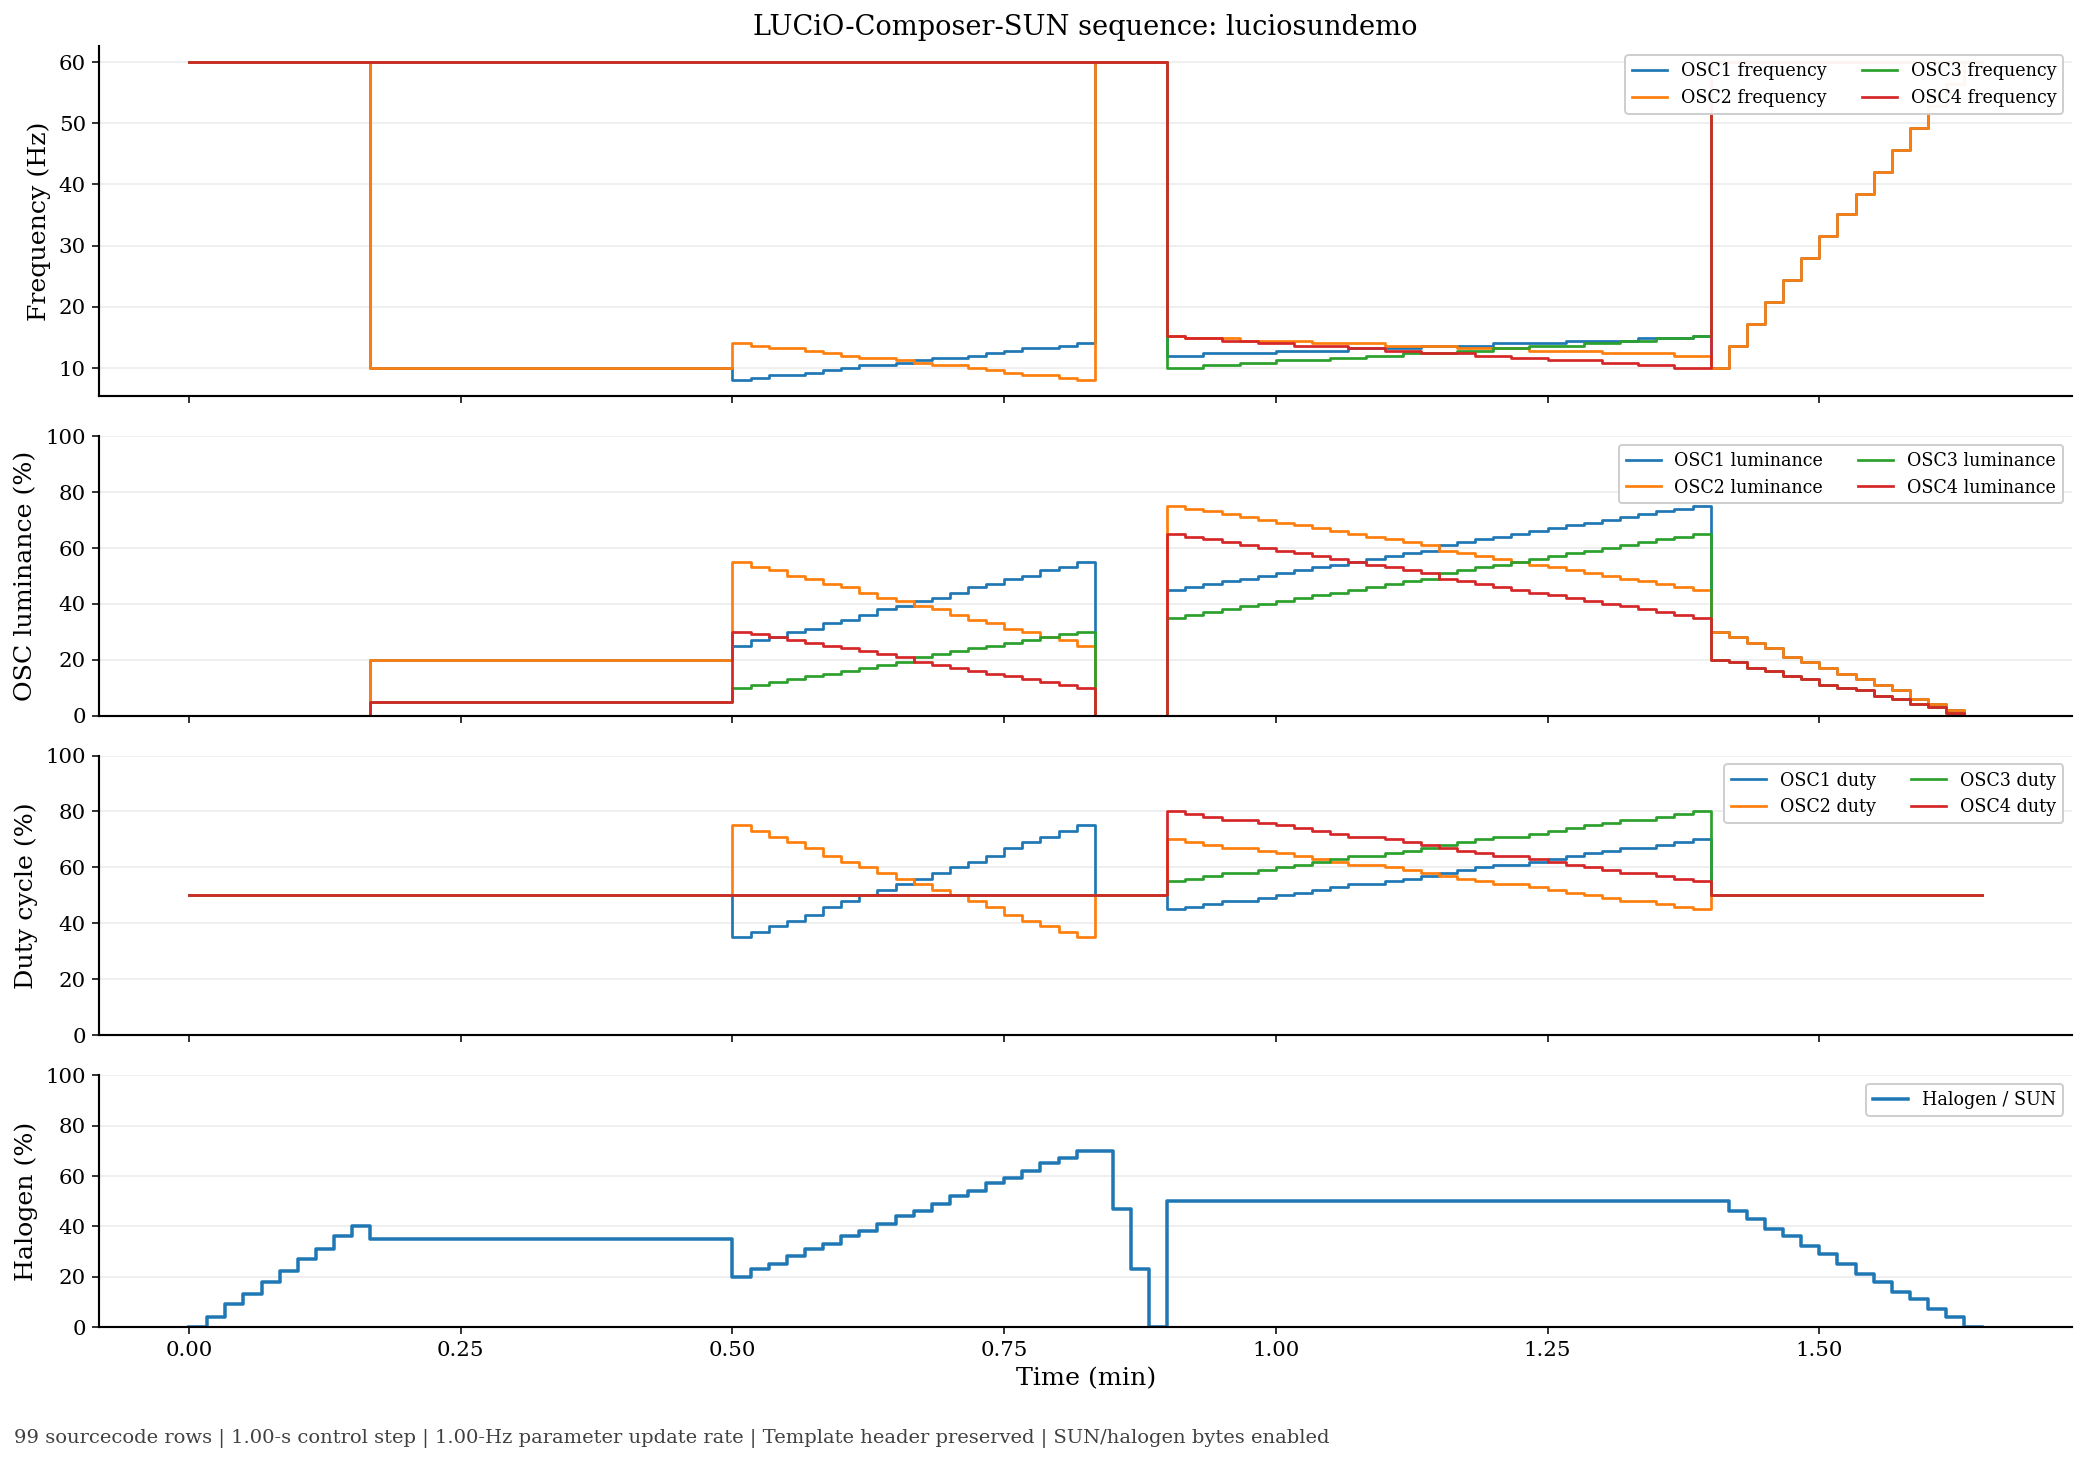

Export summary
  Sequence name: luciosundemo
  Output file: d_luciosundemo_various.lscf
  Lucia display name: spcwkdc1020904022
  Rows written: 99
  Approx exported duration: 99.00 s
  Halogen range: 0–70
  Checksum valid: True

  OSC1: freq 8.00–60.00 Hz | lum 0–75 | duty 35–75
  OSC2: freq 8.00–60.00 Hz | lum 0–75 | duty 35–75
  OSC3: freq 10.00–60.00 Hz | lum 0–65 | duty 50–80
  OSC4: freq 10.00–60.00 Hz | lum 0–65 | duty 50–80

First five halogen row-control bytes:
  row 1: halogen=0, row[40:44]=00 01 00 14
  row 2: halogen=4, row[40:44]=01 01 01 04
  row 3: halogen=9, row[40:44]=01 01 01 09
  row 4: halogen=13, row[40:44]=01 01 01 0d
  row 5: halogen=18, row[40:44]=01 01 01 12

LUCiO-Composer-SUN export complete
Copy the generated .lscf file into:
  USB Lucia/user/sourcecodes/

Then load in Lucia:
  Session editor -> D -> various -> spcwkdc1020904022

The output filename is sequence-specific, but the initial Lucia display
name is inherited from the validated template. After loadin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ============================================================
# LUCiO-COMPOSER-SUN
# Lucia Unified Control Interface for OctAVEs
# Scripted sourcecode export for Lucia/RX1 with halogen control
# ============================================================
#
# Purpose
# -------
# Generates a Lucia/RX1-compatible .lscf sourcecode from a hand-authored
# sequence rather than from audio.
#
# Each authored step can specify:
#
#   - OSC1-OSC4 frequency
#   - OSC1-OSC4 luminance
#   - OSC1-OSC4 duty cycle
#   - halogen / wash-light level
#
# Values may be fixed scalars or [start, end] pairs. [start, end] pairs
# are expanded by LUCiO into one discrete Lucia row per control step.
#
# Validated template
# ------------------
# Upload the GUI-authored dynamic-duty template:
#
#   d_spcwkdc1020904022_various.lscf
#
# This template's header/internal identity is preserved. Therefore, inside
# Lucia, generated sourcecodes will initially appear under the template's
# internal display name:
#
#   spcwkdc1020904022
#
# After loading in Lucia, save/resave as a normal session/session config
# with the desired final name.
#
# Halogen mapping
# ---------------
# Based on GUI-authored halogen test files:
#
#   halogen off: row[40:44] = 00 01 00 14
#   halogen on:  row[40:44] = 01 01 01 H
#
# where H is the halogen intensity, 0-100.
#
# Output
# ------
#   user/sourcecodes/d_<sequence_name>_various.lscf
#   debug/<sequence_name>_lucio_sun_debug.csv
#   plots/<sequence_name>_lucio_sun_plot.png
#   plots/<sequence_name>_lucio_sun_plot.pdf
#
# Recommended use
# ---------------
# Copy one generated .lscf at a time into:
#
#   USB Lucia/user/sourcecodes/
#
# Then load in Lucia:
#
#   Session editor -> D -> various -> spcwkdc1020904022
#
# ============================================================

!pip -q install numpy pandas matplotlib

from __future__ import annotations

import math
import re
import struct
import zipfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files


# ============================================================
# CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class LucioSunConfig:
    # Lucia export resolution.
    # 1.0 s is the validated default.
    control_step_seconds: float = 1.0
    displayed_seconds_tenths: int = 10
    loops_per_row: int = 1

    # Parameter bounds.
    freq_min_hz: float = 0.0
    freq_max_hz: float = 60.0
    luminance_min: int = 0
    luminance_max: int = 100
    duty_min: int = 10
    duty_max: int = 90
    halogen_min: int = 0
    halogen_max: int = 100

    # Defaults for missing oscillator fields.
    default_freq_hz: float = 60.0
    default_luminance: int = 0
    default_duty: int = 50
    default_halogen: int = 0

    # Keep OSC blocks structurally active and use luminance=0 for off states.
    # This matches the most stable LUCiO-D / LUCiO-Composer behaviour.
    keep_all_oscillators_active: bool = True

    # Plotting.
    make_sequence_plot: bool = True
    time_units: str = "min"


CFG = LucioSunConfig()


# ============================================================
# SCRIPTED SEQUENCE
# ============================================================
#
# Authoring rules:
#
# 1. Each step needs a duration in seconds.
#
# 2. Each oscillator can be specified as "osc1", "osc2", "osc3", "osc4".
#
# 3. Frequency, luminance, duty, and halogen may be:
#      - scalar: fixed for the step
#      - [start, end]: linearly expanded across exported rows
#
# 4. Missing oscillator fields fall back to:
#      freq = 60 Hz, luminance = 0, duty = 50
#
# 5. Missing halogen field falls back to:
#      halogen = 0
#
# 6. This does NOT mean Lucia stores native start/end values.
#    LUCiO-Composer-SUN expands ramps into one discrete target state per row.
#
# Convenience:
#   - osc(freq, lum, duty) for fixed oscillator values.
#   - ramp(freq=[a,b], lum=[a,b], duty=[a,b]) for oscillator ramps.
#   - off() for a dark/off oscillator.
#   - sun(level) for halogen level, fixed or ramped.
#
# ============================================================

SEQUENCE_NAME = "luciosundemo"


def osc(freq=10, lum=40, duty=50):
    return {"freq": freq, "lum": lum, "duty": duty}


def ramp(freq=10, lum=40, duty=50):
    return {"freq": freq, "lum": lum, "duty": duty}


def off():
    return {"freq": 60, "lum": 0, "duty": 50}


def sun(level=0):
    return level


STEPS = [
    {
        "label": "halogen_only_rise",
        "duration": 10,
        "halogen": sun([0, 40]),
        "osc1": off(),
        "osc2": off(),
        "osc3": off(),
        "osc4": off(),
    },
    {
        "label": "soft_wash_plus_alpha",
        "duration": 20,
        "halogen": sun(35),
        "osc1": osc(freq=10.0, lum=20, duty=50),
        "osc2": osc(freq=10.0, lum=20, duty=50),
        "osc3": osc(freq=60, lum=5, duty=50),
        "osc4": osc(freq=60, lum=5, duty=50),
    },
    {
        "label": "osc_cross_ramp_sun_rise",
        "duration": 20,
        "halogen": sun([20, 70]),
        "osc1": ramp(freq=[8.0, 14.0], lum=[25, 55], duty=[35, 75]),
        "osc2": ramp(freq=[14.0, 8.0], lum=[55, 25], duty=[75, 35]),
        "osc3": ramp(freq=[60, 60], lum=[10, 30], duty=[50, 50]),
        "osc4": ramp(freq=[60, 60], lum=[30, 10], duty=[50, 50]),
    },
    {
        "label": "sun_dark_reset",
        "duration": 4,
        "halogen": sun([70, 0]),
        "osc1": off(),
        "osc2": off(),
        "osc3": off(),
        "osc4": off(),
    },
    {
        "label": "peak_with_sun",
        "duration": 30,
        "halogen": sun(50),
        "osc1": ramp(freq=[12.0, 15.0], lum=[45, 75], duty=[45, 70]),
        "osc2": ramp(freq=[15.0, 12.0], lum=[75, 45], duty=[70, 45]),
        "osc3": ramp(freq=[10.0, 15.0], lum=[35, 65], duty=[55, 80]),
        "osc4": ramp(freq=[15.0, 10.0], lum=[65, 35], duty=[80, 55]),
    },
    {
        "label": "cooldown",
        "duration": 15,
        "halogen": sun([50, 0]),
        "osc1": ramp(freq=[10.0, 60], lum=[30, 0], duty=[50, 50]),
        "osc2": ramp(freq=[10.0, 60], lum=[30, 0], duty=[50, 50]),
        "osc3": ramp(freq=[60, 60], lum=[20, 0], duty=[50, 50]),
        "osc4": ramp(freq=[60, 60], lum=[20, 0], duty=[50, 50]),
    },
]


# ============================================================
# LUCIA/RX1 BINARY CONSTANTS
# ============================================================

HEADER_LEN = 132
ROW_LEN = 56
CHECKSUM_LEN = 1

NAME_FIELD_OFFSET = 24
NAME_FIELD_LEN = 56

OSC_NAMES = ["osc1", "osc2", "osc3", "osc4"]
DUTY_OFFSETS = [3, 11, 19, 27]


# ============================================================
# LOW-LEVEL LUCIA HELPERS
# ============================================================

def lucia_xor_checksum(data_without_checksum: bytes) -> int:
    checksum = 0
    for byte in data_without_checksum:
        checksum ^= byte
    return checksum


def finalize_lucia_file(buffer: bytearray) -> bytearray:
    buffer = bytearray(buffer)
    buffer[-1] = lucia_xor_checksum(buffer[:-1])
    return buffer


def verify_lucia_checksum(data: bytes) -> bool:
    return data[-1] == lucia_xor_checksum(data[:-1])


def read_internal_name(data: bytes) -> str:
    raw = bytes(data[NAME_FIELD_OFFSET:NAME_FIELD_OFFSET + NAME_FIELD_LEN])
    raw = raw.split(b"\x00", 1)[0]
    return raw.decode("ascii", errors="replace")


def sanitize_filename_stem(name: str, max_len: int = 18) -> str:
    stem = Path(str(name)).stem.lower()
    stem = re.sub(r"[^a-z0-9]+", "", stem)

    if not stem:
        stem = "luciosun"

    if stem[0].isdigit():
        stem = "l" + stem

    return stem[:max_len]


def parse_lucia_rows(data: bytes) -> list[bytearray]:
    n_rows = (len(data) - HEADER_LEN - CHECKSUM_LEN) // ROW_LEN
    expected_len = HEADER_LEN + n_rows * ROW_LEN + CHECKSUM_LEN

    if len(data) != expected_len:
        raise ValueError(
            f"Invalid .lscf size: {len(data)} bytes. "
            f"Expected 132 + 56*N + 1 bytes."
        )

    return [
        bytearray(data[HEADER_LEN + i * ROW_LEN:HEADER_LEN + (i + 1) * ROW_LEN])
        for i in range(n_rows)
    ]


def main_cycle_seconds_from_row(row: bytes) -> float:
    stored = struct.unpack("<H", bytes(row[44:46]))[0]
    if stored <= 0:
        return 2.5
    return 2500.0 / float(stored)


def clamp_byte(value: float) -> int:
    return int(np.clip(round(float(value)), 0, 255))


def cycles_from_hz(freq_hz: float, main_cycle_seconds: float) -> int:
    cycles = int(round(float(freq_hz) * float(main_cycle_seconds)))
    return int(np.clip(cycles, 1, 255))


# ============================================================
# SCRIPT EXPANSION
# ============================================================

def value_at(spec, position: float):
    """
    Return scalar value at a normalized position in a step.

    spec may be:
      - scalar
      - [start, end]
      - tuple(start, end)
    """
    if isinstance(spec, (list, tuple, np.ndarray)):
        if len(spec) != 2:
            raise ValueError(f"Ramp values must have length 2. Got: {spec}")
        return float(spec[0]) + position * (float(spec[1]) - float(spec[0]))

    return float(spec)


def normalize_osc_spec(osc_spec: dict | None, cfg: LucioSunConfig = CFG) -> dict:
    if osc_spec is None:
        osc_spec = {}

    return {
        "freq": osc_spec.get("freq", cfg.default_freq_hz),
        "lum": osc_spec.get("lum", cfg.default_luminance),
        "duty": osc_spec.get("duty", cfg.default_duty),
    }


def expand_script_to_control_table(
    steps: list[dict],
    cfg: LucioSunConfig = CFG
) -> pd.DataFrame:
    rows = []
    current_time = 0.0
    row_index = 1

    if cfg.control_step_seconds <= 0:
        raise ValueError("control_step_seconds must be positive.")

    for step_index, step in enumerate(steps, start=1):
        duration = float(step["duration"])
        label = step.get("label", f"step_{step_index:03d}")

        if duration <= 0:
            continue

        n_rows = max(1, int(math.ceil(duration / cfg.control_step_seconds)))

        for local_i in range(n_rows):
            if n_rows == 1:
                pos = 0.0
            else:
                pos = local_i / (n_rows - 1)

            halogen_spec = step.get("halogen", cfg.default_halogen)
            halogen = value_at(halogen_spec, pos)
            halogen = int(np.clip(round(halogen), cfg.halogen_min, cfg.halogen_max))

            row = {
                "row": row_index,
                "time_sec": current_time + local_i * cfg.control_step_seconds,
                "step_index": step_index,
                "step_label": label,
                "step_duration_sec": duration,
                "step_position": pos,
                "halogen": halogen,
            }

            for osc_name in OSC_NAMES:
                spec = normalize_osc_spec(step.get(osc_name), cfg)

                freq = value_at(spec["freq"], pos)
                lum = value_at(spec["lum"], pos)
                duty = value_at(spec["duty"], pos)

                freq = float(np.clip(freq, cfg.freq_min_hz, cfg.freq_max_hz))
                lum = int(np.clip(round(lum), cfg.luminance_min, cfg.luminance_max))
                duty = int(np.clip(round(duty), cfg.duty_min, cfg.duty_max))

                row[f"{osc_name}_freq_hz"] = freq
                row[f"{osc_name}_lum"] = lum
                row[f"{osc_name}_duty"] = duty

            rows.append(row)
            row_index += 1

        current_time += duration

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("The scripted sequence produced no rows.")

    return df


# ============================================================
# LUCIA ROW GENERATION
# ============================================================

def write_halogen_bytes(row: bytearray, halogen: int) -> None:
    """
    Write halogen/wash-light control bytes.

    Empirically observed GUI-authored patterns:
      halogen off: 00 01 00 14
      halogen on:  01 01 01 H

    H is the halogen intensity byte.
    """
    halogen = int(np.clip(round(halogen), 0, 100))

    if halogen <= 0:
        row[40:44] = bytes([0x00, 0x01, 0x00, 0x14])
    else:
        row[40:44] = bytes([0x01, 0x01, 0x01, halogen])


def patch_lucia_sun_row(
    template_row: bytes,
    control_row: pd.Series,
    cfg: LucioSunConfig = CFG
) -> tuple[bytearray, dict]:
    row = bytearray(template_row)
    main_cycle_seconds = main_cycle_seconds_from_row(row)

    halogen = int(control_row["halogen"])

    debug = {
        "main_cycle_seconds": main_cycle_seconds,
        "displayed_row_seconds": cfg.displayed_seconds_tenths / 10.0,
        "halogen": halogen,
        "row_40_44_hex": None,
        "row_40_56_hex": None,
    }

    for osc_idx, osc_name in enumerate(OSC_NAMES):
        base = osc_idx * 8

        freq_hz = float(control_row[f"{osc_name}_freq_hz"])
        lum = int(control_row[f"{osc_name}_lum"])
        duty = int(control_row[f"{osc_name}_duty"])
        cycles = cycles_from_hz(freq_hz, main_cycle_seconds)

        active_flag = 1 if cfg.keep_all_oscillators_active else int(lum > 0)

        row[base + 0] = active_flag
        row[base + 1] = active_flag
        row[base + 2] = 100
        row[base + 3] = clamp_byte(duty)
        row[base + 4] = clamp_byte(cycles)
        row[base + 5] = 0
        row[base + 6] = active_flag
        row[base + 7] = 0

        row[32 + osc_idx] = clamp_byte(lum)
        row[36 + osc_idx] = active_flag

        debug[f"{osc_name}_cycles"] = cycles
        debug[f"{osc_name}_achieved_freq_hz"] = cycles / main_cycle_seconds

    write_halogen_bytes(row, halogen)

    # Sourcecode row timing/control convention.
    # Keep the validated D/various 1-s row structure.
    row[46] = 1
    row[47] = 1
    row[48] = clamp_byte(cfg.displayed_seconds_tenths)
    row[49] = 0
    row[50] = 0
    row[51] = 0

    row[52:56] = struct.pack("<I", int(cfg.loops_per_row))

    debug["row_40_44_hex"] = row[40:44].hex(" ")
    debug["row_40_56_hex"] = row[40:56].hex(" ")

    return row, debug


def build_lucia_sun_sourcecode(
    template_data: bytes,
    control_df: pd.DataFrame,
    output_path: str,
    cfg: LucioSunConfig = CFG
) -> tuple[str, pd.DataFrame]:
    template_data = bytearray(template_data)
    template_rows = parse_lucia_rows(template_data)
    template_row = template_rows[0]

    out = bytearray()
    out.extend(template_data[:HEADER_LEN])

    debug_rows = []

    for _, control_row in control_df.iterrows():
        patched_row, row_debug = patch_lucia_sun_row(template_row, control_row, cfg)
        out.extend(patched_row)

        debug_row = dict(control_row)
        debug_row.update(row_debug)
        debug_rows.append(debug_row)

    out.extend(b"\x00")
    out = finalize_lucia_file(out)

    if not verify_lucia_checksum(out):
        raise RuntimeError("Final Lucia XOR checksum failed.")

    Path(output_path).write_bytes(out)

    return output_path, pd.DataFrame(debug_rows)


# ============================================================
# SEQUENCE PLOT
# ============================================================

def make_sun_plot(
    debug_df: pd.DataFrame,
    stem: str,
    cfg: LucioSunConfig = CFG
) -> tuple[str, str]:
    time_sec = debug_df["time_sec"].to_numpy(dtype=float)

    if cfg.time_units.lower().startswith("min"):
        t = time_sec / 60.0
        final_t = (time_sec[-1] + cfg.control_step_seconds) / 60.0
        x_label = "Time (min)"
    else:
        t = time_sec
        final_t = time_sec[-1] + cfg.control_step_seconds
        x_label = "Time (s)"

    t_step = np.append(t, final_t)

    def step_values(values):
        values = np.asarray(values, dtype=float)
        return np.append(values, values[-1])

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Palatino", "Palatino Linotype", "DejaVu Serif"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.1,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 9,
        "figure.dpi": 140,
    })

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(15, 10.5),
        sharex=True,
        gridspec_kw={"height_ratios": [1.25, 1.0, 1.0, 0.9]}
    )

    ax_freq, ax_lum, ax_duty, ax_sun = axes

    for osc_name in OSC_NAMES:
        ax_freq.step(
            t_step,
            step_values(debug_df[f"{osc_name}_achieved_freq_hz"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} frequency"
        )

    ax_freq.set_ylabel("Frequency (Hz)")
    ax_freq.set_title(f"LUCiO-Composer-SUN sequence: {stem}")
    ax_freq.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_freq.grid(axis="y", alpha=0.25)

    for osc_name in OSC_NAMES:
        ax_lum.step(
            t_step,
            step_values(debug_df[f"{osc_name}_lum"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} luminance"
        )

    ax_lum.set_ylabel("OSC luminance (%)")
    ax_lum.set_ylim(0, 100)
    ax_lum.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_lum.grid(axis="y", alpha=0.25)

    for osc_name in OSC_NAMES:
        ax_duty.step(
            t_step,
            step_values(debug_df[f"{osc_name}_duty"]),
            where="post",
            linewidth=1.4,
            label=f"{osc_name.upper()} duty"
        )

    ax_duty.set_ylabel("Duty cycle (%)")
    ax_duty.set_ylim(0, 100)
    ax_duty.legend(loc="upper right", ncol=2, frameon=True, framealpha=0.95)
    ax_duty.grid(axis="y", alpha=0.25)

    ax_sun.step(
        t_step,
        step_values(debug_df["halogen"]),
        where="post",
        linewidth=1.8,
        label="Halogen / SUN"
    )

    ax_sun.set_ylabel("Halogen (%)")
    ax_sun.set_ylim(0, 100)
    ax_sun.set_xlabel(x_label)
    ax_sun.legend(loc="upper right", frameon=True, framealpha=0.95)
    ax_sun.grid(axis="y", alpha=0.25)

    footer = (
        f"{len(debug_df)} sourcecode rows | "
        f"{cfg.control_step_seconds:.2f}-s control step | "
        f"{1 / cfg.control_step_seconds:.2f}-Hz parameter update rate | "
        "Template header preserved | "
        "SUN/halogen bytes enabled"
    )

    fig.text(0.01, 0.01, footer, ha="left", va="bottom", fontsize=10, alpha=0.75)
    plt.tight_layout(rect=[0, 0.035, 1, 1])

    png_path = f"/content/{stem}_lucio_sun_plot.png"
    pdf_path = f"/content/{stem}_lucio_sun_plot.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    return png_path, pdf_path


# ============================================================
# COLAB RUNNER
# ============================================================

sequence_stem = sanitize_filename_stem(SEQUENCE_NAME, max_len=18)

print("LUCiO-Composer-SUN sourcecode export")
print("")
print("Step 1: upload the validated dynamic-duty Lucia template:")
print("  d_spcwkdc1020904022_various.lscf")
print("")

template_upload = files.upload()

template_filename = next(iter(template_upload.keys()))
template_data = bytearray(Path(template_filename).read_bytes())
template_rows = parse_lucia_rows(template_data)

if not verify_lucia_checksum(template_data):
    raise RuntimeError("Template checksum is invalid.")

template_display_name = read_internal_name(template_data)

print("Template loaded")
print(f"  File: {template_filename}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Template rows: {len(template_rows)}")
print(f"  First-row OSC duties: {[template_rows[0][off] for off in DUTY_OFFSETS]}")
print(f"  First-row row[40:44]: {template_rows[0][40:44].hex(' ')}")
print("")

print("Expanding scripted sequence")
control_df = expand_script_to_control_table(STEPS, CFG)

lscf_path = f"/content/d_{sequence_stem}_various.lscf"
debug_path = f"/content/{sequence_stem}_lucio_sun_debug.csv"

_, debug_df = build_lucia_sun_sourcecode(
    template_data=template_data,
    control_df=control_df,
    output_path=lscf_path,
    cfg=CFG
)

debug_df.to_csv(debug_path, index=False)

plot_paths = []
if CFG.make_sequence_plot:
    plot_paths = list(make_sun_plot(debug_df, sequence_stem, CFG))

total_duration = len(debug_df) * CFG.control_step_seconds

print("Export summary")
print(f"  Sequence name: {SEQUENCE_NAME}")
print(f"  Output file: {Path(lscf_path).name}")
print(f"  Lucia display name: {template_display_name}")
print(f"  Rows written: {len(debug_df)}")
print(f"  Approx exported duration: {total_duration:.2f} s")
print(f"  Halogen range: {int(debug_df['halogen'].min())}–{int(debug_df['halogen'].max())}")
print(f"  Checksum valid: {verify_lucia_checksum(Path(lscf_path).read_bytes())}")
print("")

for osc_name in OSC_NAMES:
    fmin = debug_df[f"{osc_name}_achieved_freq_hz"].min()
    fmax = debug_df[f"{osc_name}_achieved_freq_hz"].max()
    lmin = debug_df[f"{osc_name}_lum"].min()
    lmax = debug_df[f"{osc_name}_lum"].max()
    dmin = debug_df[f"{osc_name}_duty"].min()
    dmax = debug_df[f"{osc_name}_duty"].max()

    print(
        f"  {osc_name.upper()}: "
        f"freq {fmin:.2f}–{fmax:.2f} Hz | "
        f"lum {int(lmin)}–{int(lmax)} | "
        f"duty {int(dmin)}–{int(dmax)}"
    )

print("")
print("First five halogen row-control bytes:")
for i in range(min(5, len(debug_df))):
    print(
        f"  row {i + 1}: "
        f"halogen={int(debug_df.loc[i, 'halogen'])}, "
        f"row[40:44]={debug_df.loc[i, 'row_40_44_hex']}"
    )

zip_path = "/content/lucio_sun_exports.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(lscf_path, arcname=f"user/sourcecodes/{Path(lscf_path).name}")
    z.write(debug_path, arcname=f"debug/{Path(debug_path).name}")

    for plot_path in plot_paths:
        z.write(plot_path, arcname=f"plots/{Path(plot_path).name}")

print("")
print("============================================================")
print("LUCiO-Composer-SUN export complete")
print("============================================================")
print("Copy the generated .lscf file into:")
print("  USB Lucia/user/sourcecodes/")
print("")
print("Then load in Lucia:")
print(f"  Session editor -> D -> various -> {template_display_name}")
print("")
print("The output filename is sequence-specific, but the initial Lucia display")
print("name is inherited from the validated template. After loading, resave")
print("the sourcecode/session in Lucia under the desired final name.")
print("")
print("Export settings:")
print(f"  Control step: {CFG.control_step_seconds:.2f} s")
print(f"  Parameter update rate: {1 / CFG.control_step_seconds:.2f} Hz")
print(f"  Row duration byte: {CFG.displayed_seconds_tenths}")
print(f"  Halogen bounds: {CFG.halogen_min}–{CFG.halogen_max}")
print("============================================================")

files.download(zip_path)